# Installar apenas uma vez para evitar conflito com a versão antigado do numpy

In [1]:
# pip install bluepysnap

# Iniciate Collab on gdrive

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
# cd '/content/drive/MyDrive/Brain_Matrix/S1_opto_Thal'

# Install neuron netpyne bluepysnap in the Google collab

In [4]:
# pip install pandas==1.5.3 numpy==1.23.5 neuron==8.2.2 netpyne==1.0.5

In [5]:
# !nrnivmodl mod2/

# Load cells info


In [6]:
import numpy as np
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
from bluepysnap import Circuit
from bluepysnap.bbp import Cell

CircuitPath = 'O1_data_physiology/' # edges files not inclued in https://github.com/FernandoSBorges/
circuit_path = CircuitPath + 'circuit_config.json'
circuit = Circuit(circuit_path)
cells = circuit.nodes["S1nonbarrel_neurons"]
nodesinfo = cells.get()

%matplotlib inline

In [7]:
nodesinfo[nodesinfo['layer'] == '4'].head()

,etype,exc_mini_frequency,hexagon,inh_mini_frequency,layer,me_combo,model_template,model_type,morph_class,morphology,...,x,x_new,y,y_new,z,z_new,@dynamics:holding_current,@dynamics:input_resistance,@dynamics:resting_potential,@dynamics:threshold_current
node_ids,,,,,,,,,,,,,,,,,,,,,
108727,dSTUT,0.010108,2,0.233243,4,dSTUT_L4BP_L4_BP_4_C300797C-I1_-_Scale_x1.000_...,hoc:dSTUT_L4BP,biophysical,INT,C300797C-I1_-_Scale_x1.000_y0.975_z1.000_-_Clo...,...,3918.383222,345.100991,-882.079924,368.523207,-1946.094942,1431.980963,-0.048744,103.355850,-77.048584,0.092756
108728,bAC,0.010108,1,0.233243,4,bAC_L23BTC_L4_BP_4_rp140319_ChC_3_idA_-_Scale_...,hoc:bAC_L23BTC,biophysical,INT,rp140319_ChC_3_idA_-_Scale_x1.000_y0.975_z1.00...,...,4140.810336,179.239589,-766.305463,605.707003,-2090.662966,1435.342921,-0.011682,606.258118,-76.392754,0.024155
108729,cNAC,0.010108,0,0.233243,4,cNAC_L6NGC_L4_BP_4_C300797C-I1_-_Scale_x1.000_...,hoc:cNAC_L6NGC,biophysical,INT,C300797C-I1_-_Scale_x1.000_y0.950_z1.000_-_Clo...,...,3953.899058,722.166787,-1279.341226,593.262166,-2143.970161,1357.507449,-0.025396,385.013672,-74.105980,0.033770
108730,cACint,0.010108,0,0.233243,4,cACint_L4CHC_L4_BP_4_rp140319_ChC_3_idA_-_Scal...,hoc:cACint_L4CHC,biophysical,INT,rp140319_ChC_3_idA_-_Scale_x1.000_y0.975_z1.00...,...,4214.386218,740.411420,-1362.666051,842.778874,-2201.251811,1481.951494,-0.014442,636.180054,-73.075333,0.015156
108731,cACint,0.010108,0,0.233243,4,cACint_L4CHC_L4_BP_4_rp140319_ChC_3_idA_-_Scal...,hoc:cACint_L4CHC,biophysical,INT,rp140319_ChC_3_idA_-_Scale_x1.000_y1.025_z1.00...,...,4184.420803,714.604811,-1328.656268,916.399225,-2366.952165,1328.898361,-0.014949,620.984924,-72.957344,0.015535


In [8]:
nodesinfo.keys()

Index(['etype', 'exc_mini_frequency', 'hexagon', 'inh_mini_frequency', 'layer',
       'me_combo', 'model_template', 'model_type', 'morph_class', 'morphology',
       'mtype', 'orientation_w', 'orientation_x', 'orientation_y',
       'orientation_z', 'region', 'synapse_class', 'x', 'x_new', 'y', 'y_new',
       'z', 'z_new', '@dynamics:holding_current', '@dynamics:input_resistance',
       '@dynamics:resting_potential', '@dynamics:threshold_current'],
      dtype='object')

In [9]:
def distance3D(gidpre,gidpost):
    return np.sqrt(np.power(nodesinfo['x'][gidpre]-nodesinfo['x'][gidpost],2)+np.power(nodesinfo['y'][gidpre]-nodesinfo['y'][gidpost],2)+np.power(nodesinfo['z'][gidpre]-nodesinfo['z'][gidpost],2))

def distance2D(gidpre,gidpost):
    return np.sqrt(np.power(nodesinfo['x'][gidpre]-nodesinfo['x'][gidpost],2)+np.power(nodesinfo['y'][gidpre]-nodesinfo['y'][gidpost],2))

def distance2Dmean(gidpre, mean_x, mean_y):
    return np.sqrt(np.power(nodesinfo['x_new'][gidpre]-mean_x,2)+np.power(nodesinfo['y_new'][gidpre]-mean_y,2))

print(cells.property_values(Cell.REGION))

mtypes = sorted(cells.property_values(Cell.MTYPE))

i = 0
mntypes = {}
for mn in sorted(mtypes):
    mntypes[mn] = i
    i+=1

{'S1FL', 'S1DZ', 'S1J'}


In [10]:
f = open('node_sets.json')
node_sets = json.load(f)

mean_x, mean_y = np.mean(nodesinfo['x_new']), np.mean(nodesinfo['y_new'])
node_gid = []
nodepremtype_new = []
mtype_new = []


node_gid = []
hoclist = []
Morpholist = []
node_threshold_current = []
node_holding_current = []


hex = 'hex0'
for gid in node_sets['hex0']['node_id']:
# for gid in [117619, 142340, 142768, 142891, 141786,138337, 142077, 138315, 141829, 142671, 142352, 138475, 141536, 142859, 142058, 142814]:
# for gid in [141766, 138220, 108767, 108729, 108749, 138433, 141757, 141803, 138337]:
    if 'L4_' in nodesinfo['mtype'][gid] and distance2Dmean(gid, mean_x, mean_y) > 0.0 and distance2Dmean(gid, mean_x, mean_y) < 50.0 and 'EXC' in nodesinfo['synapse_class'][gid]:
        nodepremtype_new.append(mntypes[nodesinfo['mtype'][gid]])
        if nodesinfo['mtype'][gid] not in mtype_new:
            mtype_new.append(nodesinfo['mtype'][gid])

        iV70 = (-73.0 - nodesinfo['@dynamics:resting_potential'][gid])/nodesinfo['@dynamics:input_resistance'][gid]

        # print(len(node_gid),gid,nodesinfo['synapse_class'][gid],nodesinfo['mtype'][gid],nodesinfo['model_template'][gid],nodesinfo['morphology'][gid],hex,distance2Dmean(gid, mean_x, mean_y))
        print("%d \t%d %s %s %.1f %.2f %.1f %.2f" % (len(node_gid),gid,nodesinfo['synapse_class'][gid],nodesinfo['mtype'][gid], 
                                                     1000*(nodesinfo['@dynamics:threshold_current'][gid]+nodesinfo['@dynamics:holding_current'][gid]-iV70),nodesinfo['@dynamics:resting_potential'][gid],
                                                     1000*iV70,nodesinfo['@dynamics:input_resistance'][gid]))

        current1 = cells.get(gid,['@dynamics:threshold_current']).values[0]
        holding_current1 = cells.get(gid,['@dynamics:holding_current']).values[0]
        # print("%d %.5f %.5f" % (gid,current1,holding_current1))

        node_gid.append(gid)
        hoclist.append(nodesinfo['model_template'][gid][4:])
        Morpholist.append(nodesinfo['morphology'][gid])
        node_threshold_current.append(current1)
        node_holding_current.append(holding_current1)



# non central col
# for hex in node_sets['hex_O1']:
#     for gid in node_sets[hex]['node_id']:
#         if 'L4' in nodesinfo['mtype'][gid] and distance2Dmean(gid, mean_x, mean_y) > 500.0 and distance2Dmean(gid, mean_x, mean_y) < 502.0:
#             node_gid.append(gid)
#             nodepremtype_new.append(mntypes[nodesinfo['mtype'][gid]])
#             if nodesinfo['mtype'][gid] not in mtype_new:
#                 mtype_new.append(nodesinfo['mtype'][gid])

#             print(len(node_gid),gid,nodesinfo['mtype'][gid],hex,distance2Dmean(gid, mean_x, mean_y))

0 	109126 EXC L4_UPC 28.3 -78.55 43.6 127.30
1 	109170 EXC L4_UPC 52.9 -78.23 62.0 84.49
2 	109310 EXC L4_UPC 3.2 -78.98 20.9 285.92
3 	109354 EXC L4_UPC 12.7 -76.18 15.6 204.69
4 	109439 EXC L4_UPC 22.8 -75.99 19.0 157.70
5 	109632 EXC L4_UPC 18.5 -78.87 36.7 160.13
6 	109685 EXC L4_UPC 21.9 -78.63 34.8 161.86
7 	109872 EXC L4_UPC 31.8 -75.34 17.4 134.59
8 	110044 EXC L4_UPC 12.4 -78.45 32.3 168.64
9 	110155 EXC L4_UPC 23.3 -75.93 18.8 155.89
10 	110359 EXC L4_UPC 65.7 -78.25 70.5 74.48
11 	110557 EXC L4_UPC 46.9 -78.36 67.0 80.09
12 	110595 EXC L4_UPC 52.9 -78.23 62.0 84.49
13 	110675 EXC L4_UPC 20.1 -75.24 15.0 149.30
14 	111043 EXC L4_UPC 26.4 -78.45 42.2 129.18
15 	111183 EXC L4_UPC 71.5 -78.04 68.8 73.19
16 	111324 EXC L4_UPC 15.4 -77.18 14.1 296.33
17 	111850 EXC L4_UPC 6.9 -77.39 13.5 324.62
18 	112199 EXC L4_UPC 5.8 -78.94 21.6 274.88
19 	112410 EXC L4_UPC 22.7 -78.36 37.5 142.77
20 	112417 EXC L4_UPC 22.5 -78.70 32.5 175.24
21 	112501 EXC L4_UPC 26.8 -76.28 22.9 142.76
22 	11

# Testing over all reconstruct cells

In [11]:
from netpyne import specs, sim

# Network parameters
netParams = specs.NetParams()  # object of class NetParams to store the network parameters

In [12]:
cellName_list = {}
cellName_list2 = []
gid_list = {}

Epops = []
Ipops = []

cellName_list2 = []

# node_gid = [139867, 141213, 141369, 133426, 135956, 137858, 114264, 114284, 115007]

node_gid

for gid in node_gid:
# for gid in [108767, 141766, 138433, 139867, 141213, 141369, 133426, 135956, 137858, 114264, 114284, 115007]:
# for gid in [108767, 141766, 138433, 141213, 133426, 135956,  137858, 114264]:
# for gid in [114264]:

    cellName = nodesinfo['mtype'][gid] + '_' + nodesinfo['etype'][gid]

    cellName_list2.append(cellName)

    cellName_list[gid] = cellName + '_' + str(len(cellName_list2)-1)
    gid_list[cellName + '_' + str(len(cellName_list2)-1)] = gid

    print('%s %s %s 1 1 %d' % (cellName + '_' + str(len(cellName_list2)-1),nodesinfo['mtype'][gid],nodesinfo['etype'][gid],gid))

    if 'cADpyr' in cellName:
        Epops.append(cellName + '_' + str(len(cellName_list2)-1))
    else:
        Ipops.append(cellName + '_' + str(len(cellName_list2)-1))

L4_UPC_cADpyr_0 L4_UPC cADpyr 1 1 109126
L4_UPC_cADpyr_1 L4_UPC cADpyr 1 1 109170
L4_UPC_cADpyr_2 L4_UPC cADpyr 1 1 109310
L4_UPC_cADpyr_3 L4_UPC cADpyr 1 1 109354
L4_UPC_cADpyr_4 L4_UPC cADpyr 1 1 109439
L4_UPC_cADpyr_5 L4_UPC cADpyr 1 1 109632
L4_UPC_cADpyr_6 L4_UPC cADpyr 1 1 109685
L4_UPC_cADpyr_7 L4_UPC cADpyr 1 1 109872
L4_UPC_cADpyr_8 L4_UPC cADpyr 1 1 110044
L4_UPC_cADpyr_9 L4_UPC cADpyr 1 1 110155
L4_UPC_cADpyr_10 L4_UPC cADpyr 1 1 110359
L4_UPC_cADpyr_11 L4_UPC cADpyr 1 1 110557
L4_UPC_cADpyr_12 L4_UPC cADpyr 1 1 110595
L4_UPC_cADpyr_13 L4_UPC cADpyr 1 1 110675
L4_UPC_cADpyr_14 L4_UPC cADpyr 1 1 111043
L4_UPC_cADpyr_15 L4_UPC cADpyr 1 1 111183
L4_UPC_cADpyr_16 L4_UPC cADpyr 1 1 111324
L4_UPC_cADpyr_17 L4_UPC cADpyr 1 1 111850
L4_UPC_cADpyr_18 L4_UPC cADpyr 1 1 112199
L4_UPC_cADpyr_19 L4_UPC cADpyr 1 1 112410
L4_UPC_cADpyr_20 L4_UPC cADpyr 1 1 112417
L4_UPC_cADpyr_21 L4_UPC cADpyr 1 1 112501
L4_UPC_cADpyr_22 L4_UPC cADpyr 1 1 112531
L4_UPC_cADpyr_23 L4_UPC cADpyr 1 1 112935
L4

In [13]:
cellsList = {}

for cellName in gid_list.keys():
    # try:
        gid = gid_list[cellName]

        MorphoName = nodesinfo['morphology'][gid] + '.asc'

        hocName = nodesinfo['model_template'][gid][4:]

        MorphologyPath = 'O1_data_physiology/morphologies/ascii'

        # MorphoName = nodesinfo['morphology'][gid]+"_gid"+str(gid)+".asc"

        print(cellName,hocName)

        cellRule = netParams.importCellParams(label=cellName, somaAtOrigin=True,
            conds={'cellType': cellName, 'cellModel': 'HH_full'},
            fileName='O1_data_physiology/emodels_hoc/' + hocName + '.hoc',
            cellName=hocName,
            cellInstance = False,
            cellArgs=[gid, MorphologyPath, MorphoName])

        # netParams.saveCellParamsRule(label=cellName, fileName=cellName+'_BBP_cellParams.json')


        # netParams.cellParams[cellName]['secs']['axon_0']['geom']['Ra'] = 2.0*netParams.cellParams[cellName]['secs']['axon_0']['geom']['Ra']

        cellsList[cellName] = [{'x': nodesinfo['x'][gid], 'y': nodesinfo['y'][gid], 'z': nodesinfo['z'][gid]}]
        # cellsList[cellName] = [{'x': nodesinfo['x'][gid] - 3000.0, 'y': nodesinfo['y'][gid] + 2000.0, 'z': nodesinfo['z'][gid] + 3500.0}]

        cellMe = cellName

        axon_pt3d_x, axon_pt3d_y, axon_pt3d_z, soma_pt3d_diam =  netParams.cellParams[cellMe]['secs']['soma_0']['geom']['pt3d'][-1]

        netParams.cellParams[cellMe]['secs']['axon_0']['geom']['diam'] = 1.0
        # netParams.cellParams[cellMe]['secs']['axon_0']['geom']['L'] = 30.0

        axon_pt3d_diam =  netParams.cellParams[cellMe]['secs']['axon_0']['geom']['diam']
        axon_pt3d_L =  netParams.cellParams[cellMe]['secs']['axon_0']['geom']['L']

        netParams.cellParams[cellMe]['secs']['axon_0']['geom']['pt3d'] = [(axon_pt3d_x, axon_pt3d_y, axon_pt3d_z, axon_pt3d_diam),
                                                                                    (axon_pt3d_x, axon_pt3d_y+axon_pt3d_L/2.0, axon_pt3d_z, axon_pt3d_diam),
                                                                                    (axon_pt3d_x, axon_pt3d_y+axon_pt3d_L, axon_pt3d_z, axon_pt3d_diam)]



        axon1_pt3d_x, axon1_pt3d_y, axon1_pt3d_z, axon_0_pt3d_diam =  netParams.cellParams[cellMe]['secs']['axon_0']['geom']['pt3d'][-1]

        # netParams.cellParams[cellMe]['secs']['axon_1']['geom']['diam'] = 0.5
        # netParams.cellParams[cellMe]['secs']['axon_1']['geom']['L'] = 30.0

        axon1_pt3d_diam =  netParams.cellParams[cellMe]['secs']['axon_1']['geom']['diam']
        axon1_pt3d_L =  netParams.cellParams[cellMe]['secs']['axon_1']['geom']['L']

        netParams.cellParams[cellMe]['secs']['axon_1']['geom']['pt3d'] = [(axon1_pt3d_x, axon1_pt3d_y, axon1_pt3d_z, axon1_pt3d_diam),
                                                                                    (axon1_pt3d_x, axon1_pt3d_y+axon1_pt3d_L/2.0, axon1_pt3d_z, axon1_pt3d_diam),
                                                                                    (axon1_pt3d_x, axon1_pt3d_y+axon1_pt3d_L, axon1_pt3d_z, axon1_pt3d_diam)]



        myelin_pt3d_x, myelin_pt3d_y, myelin_pt3d_z, axon_1_pt3d_diam =  netParams.cellParams[cellMe]['secs']['axon_1']['geom']['pt3d'][-1]

        # netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['diam'] = 0.5
        netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['L'] = 100.0

        myelin_pt3d_diam =  netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['diam']
        myelin_pt3d_L =  netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['L']

        netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['pt3d'] = [(myelin_pt3d_x, myelin_pt3d_y, myelin_pt3d_z, myelin_pt3d_diam),
                                                                                    (myelin_pt3d_x, myelin_pt3d_y+myelin_pt3d_L/2.0, myelin_pt3d_z, myelin_pt3d_diam),
                                                                                    (myelin_pt3d_x, myelin_pt3d_y+myelin_pt3d_L, myelin_pt3d_z, myelin_pt3d_diam)]

    # except:
    #     pass

# cellsList

L4_UPC_cADpyr_0 cADpyr_L4TPC
L4_UPC_cADpyr_1 cADpyr_L4TPC
L4_UPC_cADpyr_2 cADpyr_L4TPC
L4_UPC_cADpyr_3 cADpyr_L4UPC
L4_UPC_cADpyr_4 cADpyr_L4UPC
L4_UPC_cADpyr_5 cADpyr_L4TPC
L4_UPC_cADpyr_6 cADpyr_L4TPC
L4_UPC_cADpyr_7 cADpyr_L4UPC
L4_UPC_cADpyr_8 cADpyr_L4TPC
L4_UPC_cADpyr_9 cADpyr_L4UPC
L4_UPC_cADpyr_10 cADpyr_L4TPC
L4_UPC_cADpyr_11 cADpyr_L4TPC
L4_UPC_cADpyr_12 cADpyr_L4TPC
L4_UPC_cADpyr_13 cADpyr_L4UPC
L4_UPC_cADpyr_14 cADpyr_L4TPC
L4_UPC_cADpyr_15 cADpyr_L4TPC
L4_UPC_cADpyr_16 cADpyr_L4UPC
L4_UPC_cADpyr_17 cADpyr_L4UPC
L4_UPC_cADpyr_18 cADpyr_L4TPC
L4_UPC_cADpyr_19 cADpyr_L4TPC
L4_UPC_cADpyr_20 cADpyr_L4TPC
L4_UPC_cADpyr_21 cADpyr_L4UPC
L4_UPC_cADpyr_22 cADpyr_L4UPC
L4_UPC_cADpyr_23 cADpyr_L4TPC
L4_UPC_cADpyr_24 cADpyr_L4UPC
L4_UPC_cADpyr_25 cADpyr_L4UPC
L4_UPC_cADpyr_26 cADpyr_L4UPC
L4_UPC_cADpyr_27 cADpyr_L4TPC
L4_UPC_cADpyr_28 cADpyr_L4TPC
L4_UPC_cADpyr_29 cADpyr_L4UPC
L4_UPC_cADpyr_30 cADpyr_L4TPC
L4_UPC_cADpyr_31 cADpyr_L4UPC
L4_UPC_cADpyr_32 cADpyr_L4UPC
L4_UPC_cADpyr_33 cAD

In [14]:
list(netParams.cellParams[cellMe]['secs']['soma_0']['mechs'])

['CaDynamics_DC0',
 'Ca_HVA2',
 'Ca_LVAst',
 'Ih',
 'K_Pst',
 'K_Tst',
 'NaTg',
 'SK_E2',
 'SKv3_1',
 'pas']

In [15]:
# https://github.com/suny-downstate-medical-center/S1_mouse
# Layer	     height	  from	  to
# L1         0.089      0.000	0.089
# L2         0.070      0.089	0.159
# L3         0.128      0.159	0.286
# L4         0.134      0.286	0.421
# L5         0.263      0.421	0.684
# L6         0.316      0.684	1.000
# L23        0.198      0.089	0.286
# All     1378.8 um

layer = {'1':[0.0, 0.089], '2': [0.089,0.159], '3': [0.159,0.286], '23': [0.089,0.286], '4':[0.286,0.421], '5': [0.421,0.684], '6': [0.684,1.0],
'longS1': [2.2,2.3], 'longS2': [2.3,2.4]}  # normalized layer boundaries

#Th pop
ymin={'ss_RTN_o': 1688, 'ss_RTN_m': 1766, 'ss_RTN_i': 1844, 'VPL_sTC': 2000, 'VPM_sTC': 2156, 'POm_sTC_s1': 2312}
ymax={'ss_RTN_o': 1766, 'ss_RTN_m': 1844, 'ss_RTN_i': 2000, 'VPL_sTC': 2156, 'VPM_sTC': 2312, 'POm_sTC_s1': 2624}

#------------------------------------------------------------------------------
# General network parameters
#------------------------------------------------------------------------------
netParams.scale = 1.0 # Scale factor for number of cells
netParams.sizeX = 50.0 # x-dimension (horizontal length) size in um
netParams.sizeY = 1378.8 # y-dimension (vertical height or cortical depth) size in um
netParams.sizeZ = 50.0 # z-dimension (horizontal depth) size in um
netParams.shape = 'cylinder' # cylindrical (column-like) volume
netParams.rotateCellsRandomly = True

netParams.defaultThreshold = -20.0 # spike threshold, 10 mV is NetCon default, lower it for all cells
netParams.defaultDelay = 0.1 # default conn delay (ms)
netParams.propVelocity = 300.0 #  300 μm/ms (Stuart et al., 1997)
netParams.scaleConnWeightNetStims = 0.001  # weight conversion factor (from nS to uS)

#------------------------------------------------------------------------------
# load data from S1 Raster
#------------------------------------------------------------------------------
for metype in netParams.cellParams.keys():
    layernumber = metype[1:2]
    if layernumber == '2':
        netParams.popParams[metype] = {'cellType': metype, 'cellModel': 'HH_full', 'ynormRange': layer['23'],
                                            'numCells':1, 'diversity': True}
    else:
        netParams.popParams[metype] = {'cellType': metype, 'cellModel': 'HH_full', 'ynormRange': layer[layernumber],
                                            'numCells': 1, 'diversity': True}

In [16]:
netParams.popParams.keys()

odict_keys(['L4_UPC_cADpyr_0', 'L4_UPC_cADpyr_1', 'L4_UPC_cADpyr_2', 'L4_UPC_cADpyr_3', 'L4_UPC_cADpyr_4', 'L4_UPC_cADpyr_5', 'L4_UPC_cADpyr_6', 'L4_UPC_cADpyr_7', 'L4_UPC_cADpyr_8', 'L4_UPC_cADpyr_9', 'L4_UPC_cADpyr_10', 'L4_UPC_cADpyr_11', 'L4_UPC_cADpyr_12', 'L4_UPC_cADpyr_13', 'L4_UPC_cADpyr_14', 'L4_UPC_cADpyr_15', 'L4_UPC_cADpyr_16', 'L4_UPC_cADpyr_17', 'L4_UPC_cADpyr_18', 'L4_UPC_cADpyr_19', 'L4_UPC_cADpyr_20', 'L4_UPC_cADpyr_21', 'L4_UPC_cADpyr_22', 'L4_UPC_cADpyr_23', 'L4_UPC_cADpyr_24', 'L4_UPC_cADpyr_25', 'L4_UPC_cADpyr_26', 'L4_UPC_cADpyr_27', 'L4_UPC_cADpyr_28', 'L4_UPC_cADpyr_29', 'L4_UPC_cADpyr_30', 'L4_UPC_cADpyr_31', 'L4_UPC_cADpyr_32', 'L4_UPC_cADpyr_33', 'L4_UPC_cADpyr_34', 'L4_UPC_cADpyr_35', 'L4_UPC_cADpyr_36', 'L4_UPC_cADpyr_37', 'L4_UPC_cADpyr_38', 'L4_UPC_cADpyr_39', 'L4_UPC_cADpyr_40', 'L4_UPC_cADpyr_41', 'L4_UPC_cADpyr_42', 'L4_UPC_cADpyr_43', 'L4_UPC_cADpyr_44', 'L4_UPC_cADpyr_45', 'L4_UPC_cADpyr_46', 'L4_UPC_cADpyr_47', 'L4_UPC_cADpyr_48', 'L4_UPC_cADpyr_49'

In [17]:
#------------------------------------------------------------------------------
#
# SIMULATION CONFIGURATION
#
#------------------------------------------------------------------------------

cfg = specs.SimConfig()					            # object of class SimConfig to store simulation configuration

cfg.coreneuron = False

#------------------------------------------------------------------------------
# Run parameters
#------------------------------------------------------------------------------
cfg.duration = 7.0*1e3 ## Duration of the sim, in ms
cfg.dt = 0.05
cfg.seeds = {'cell': 4321, 'conn': 4321, 'stim': 1000, 'loc': 4321}
cfg.hParams = {'celsius': 34, 'v_init': -84.0}
cfg.verbose = False
cfg.createNEURONObj = True
cfg.createPyStruct = True
cfg.cvode_active = False
cfg.cvode_atol = 1e-6
cfg.cache_efficient = True
cfg.printRunTime = 0.1

cfg.includeParamsLabel = False
cfg.printPopAvgRates = True
cfg.checkErrors = False

#--------------------------------------------------------------------------
# Recording
#--------------------------------------------------------------------------
cfg.recordCells = list(netParams.popParams.keys())
# cfg.recordTraces = {'V_soma': {'sec':'soma_0', 'loc':0.5, 'var':'v'}}  ## Dict with traces to record
cfg.recordTraces = {'V_soma': {'sec':'soma_0', 'loc':0.5, 'var':'v'},
                    # 'V_axon_0': {'sec':'axon_0', 'loc':0.5, 'var':'v'},
                    # 'V_axon_1': {'sec':'axon_1', 'loc':0.5, 'var':'v'},
                    # 'V_myelin_0': {'sec':'myelin_0', 'loc':0.5, 'var':'v'},
                    # 'V_axon_15': {'sec':'axon_15', 'loc':0.5, 'var':'v'},
                    # 'V_apic_0': {'sec':'apic_0', 'loc':0.5, 'var':'v'},
                    # 'V_apic_7': {'sec':'apic_7', 'loc':0.5, 'var':'v'},
                    # 'V_apic_64': {'sec':'apic_64', 'loc':0.5, 'var':'v'},
                    # 'V_apic_86': {'sec':'apic_86', 'loc':0.5, 'var':'v'},
                    # 'V_dend_0': {'sec':'dend_0', 'loc':0.5, 'var':'v'},
                    # 'V_dend_5': {'sec':'dend_5', 'loc':0.5, 'var':'v'},
                    }
cfg.recordStim = False
cfg.recordTime = False
cfg.recordStep = 0.05

#------------------------------------------------------------------------------
# Saving
#------------------------------------------------------------------------------
cfg.simLabel = 'v0_batch0'       #   + str(cfg.cynradNumber)
cfg.saveFolder = 'exploration/data/'+cfg.simLabel
# cfg.filename =                	## Set file output name
cfg.savePickle = False	        	## Save pkl file
cfg.saveJson = False           	## Save json file
cfg.saveDataInclude = ['simData', 'simConfig', 'net', 'netParams'] ## ['simData'] ##  ['simData'] ##, , 'simConfig', 'netParams'
cfg.backupCfgFile = None 		##
cfg.gatherOnlySimData = False	##
cfg.saveCellSecs = True
cfg.saveCellConns = True

#------------------------------------------------------------------------------
# Analysis and plotting
# ------------------------------------------------------------------------------
cfg.analysis['plotRaster'] = {'include': cfg.recordCells, 'saveFig': True, 'showFig': False,'orderInverse': True, 'timeRange': [0,cfg.duration], 'figSize': (12,4), 'fontSize':4, 'markerSize':4, 'marker': 'o', 'dpi': 300}
# cfg.analysis['plot2Dnet']   = {'include': ['presyn_L23_PC_cAD','presyn_L5_TTPC2_cAD', 'presyn_VPM_sTC','L23_PC_cAD','L5_TTPC2_cAD'],'saveFig': True, 'showConns': False, 'figSize': (24,24), 'view': 'xz', 'fontSize':16}   # Plot 2D cells xy
# cfg.analysis['plotTraces'] = {'include': cfg.recordCells, 'oneFigPer': 'trace', 'overlay': True, 'timeRange': [0,cfg.duration], 'ylim': [-100,50], 'saveFig': True, 'showFig': False, 'figSize':(24,24)}

cfg.analysis['plotTraces'] = {'include': cfg.recordCells, 'oneFigPer': 'trace', 'overlay': True, 'timeRange': [0,cfg.duration], 'saveFig': False, 'showFig': True, 'figSize':(24,4)} # , 'ylim': [-90,30] Plot recorded traces for this list of cells
# cfg.analysis['plotShape'] = {'includePre':  [ii for ii in range(10)],'includePre':  [ii for ii in range(10)], 'saveFig': True, 'showFig': True, 'figSize':(12,12)}


In [18]:
for gid in node_gid: # list_pre:

    popName1 = cellName_list[gid]
    current1 = 1.0*cells.get(gid,['@dynamics:threshold_current']).values[0]
    holding_current1 = cells.get(gid,['@dynamics:holding_current']).values[0]

    # current1 = 0.3
    # holding_current1 = 0.0

    # netParams.stimSourceParams['Input_'+str(gid)] = {'type': 'IClamp', 'del': 0.0, 'dur': 2000.0, 'amp': holding_current1}
    # netParams.stimSourceParams['Inputb_'+str(gid)] = {'type': 'IClamp', 'del': 550.0, 'dur': 600.0, 'amp':current1}

    # netParams.stimTargetParams['Input->'+str(gid)] = {'source': 'Input_'+str(gid), 'sec':'soma_0', 'loc': 0.5, 'conds': {'pop':popName1}}
    # netParams.stimTargetParams['Inputb->'+str(gid)] = {'source': 'Inputb_'+str(gid), 'sec':'soma_0', 'loc': 0.5, 'conds': {'pop':popName1}}

    # for i,current1 in enumerate([-0.100, -0.060, 0.060, 0.070, 0.100, 0.200, current1+holding_current1, current1, 0.010, -0.100]):

    iV70 = (-73.0 - nodesinfo['@dynamics:resting_potential'][gid])/nodesinfo['@dynamics:input_resistance'][gid]

    print("%.3f %.3f %.3f" % (iV70, nodesinfo['@dynamics:threshold_current'][gid]+nodesinfo['@dynamics:holding_current'][gid],nodesinfo['@dynamics:resting_potential'][gid]))

    netParams.stimSourceParams['Input_'+str(gid)] = {'type': 'IClamp', 'del': 200.0, 'dur': 10000.0, 'amp': iV70}
    netParams.stimTargetParams['Input->'+str(gid)] = {'source': 'Input_'+str(gid), 'sec':'soma_0', 'loc': 0.5, 'conds': {'pop':popName1}}

    for i,current1 in enumerate([-0.100, 0.030, 0.060, 0.070, 0.100, 0.200]):
        netParams.stimSourceParams['Input_'+str(gid)+'_'+str(i)] = {'type': 'IClamp', 'del': 550.0 + i*1000.0, 'dur': 600.0, 'amp': current1}
        netParams.stimTargetParams['Input->'+str(gid)+'_'+str(i)] = {'source': 'Input_'+str(gid)+'_'+str(i), 'sec':'soma_0', 'loc': 0.5, 'conds': {'pop':popName1}}


0.044 0.072 -78.550
0.062 0.115 -78.235
0.021 0.024 -78.976
0.016 0.028 -76.184
0.019 0.042 -75.993
0.037 0.055 -78.875
0.035 0.057 -78.631
0.017 0.049 -75.341
0.032 0.045 -78.454
0.019 0.042 -75.932
0.071 0.136 -78.254
0.067 0.114 -78.365
0.062 0.115 -78.235
0.015 0.035 -75.239
0.042 0.069 -78.451
0.069 0.140 -78.035
0.014 0.030 -77.175
0.014 0.020 -77.389
0.022 0.027 -78.944
0.038 0.060 -78.359
0.033 0.055 -78.701
0.023 0.050 -76.275
0.022 0.056 -76.167
0.035 0.053 -78.838
0.018 0.029 -77.730
0.016 0.027 -77.442
0.012 0.037 -74.841
0.037 0.061 -78.049
0.027 0.046 -78.091
0.013 0.039 -75.079
0.065 0.121 -78.208
0.021 0.039 -76.231
0.023 0.077 -74.859
0.035 0.051 -78.375
0.020 0.025 -79.555
0.050 0.101 -77.588
0.031 0.113 -75.187
0.022 0.108 -74.482
0.014 0.017 -77.409
0.018 0.021 -79.473
0.015 0.037 -75.095
0.016 0.037 -75.277
0.014 0.035 -75.117
0.035 0.055 -78.277
0.037 0.140 -75.289
0.071 0.140 -78.163
0.014 0.030 -75.677
0.017 0.019 -79.379
0.027 0.088 -75.556
0.018 0.048 -75.312


In [19]:
netParams.stimSourceParams

{Input_109126: {'type': 'IClamp', 'del': 200.0, 'dur': 10000.0, 'amp': 0.04359710256397809}, Input_109126_0: {'type': 'IClamp', 'del': 550.0, 'dur': 600.0, 'amp': -0.1}, Input_109126_1: {'type': 'IClamp', 'del': 1550.0, 'dur': 600.0, 'amp': 0.03}, Input_109126_2: {'type': 'IClamp', 'del': 2550.0, 'dur': 600.0, 'amp': 0.06}, Input_109126_3: {'type': 'IClamp', 'del': 3550.0, 'dur': 600.0, 'amp': 0.07}, Input_109126_4: {'type': 'IClamp', 'del': 4550.0, 'dur': 600.0, 'amp': 0.1}, Input_109126_5: {'type': 'IClamp', 'del': 5550.0, 'dur': 600.0, 'amp': 0.2}, Input_109170: {'type': 'IClamp', 'del': 200.0, 'dur': 10000.0, 'amp': 0.06195415280904071}, Input_109170_0: {'type': 'IClamp', 'del': 550.0, 'dur': 600.0, 'amp': -0.1}, Input_109170_1: {'type': 'IClamp', 'del': 1550.0, 'dur': 600.0, 'amp': 0.03}, Input_109170_2: {'type': 'IClamp', 'del': 2550.0, 'dur': 600.0, 'amp': 0.06}, Input_109170_3: {'type': 'IClamp', 'del': 3550.0, 'dur': 600.0, 'amp': 0.07}, Input_109170_4: {'type': 'IClamp', 'del

In [20]:
# #------------------------------------------------------------------------------
# # Current inputs
# #------------------------------------------------------------------------------
# cfg.addIClamp = True  # decrease the transient

# cfg.IClamp = []
# cfg.IClampnumber = 0

# for pop in Epops:
#   cfg.IClamp.append({'pop': pop, 'sec': 'soma', 'loc': 0.5, 'start': 550, 'dur': 600, 'amp': 0.2}) #pA
#   cfg.IClampnumber=cfg.IClampnumber+1

# for pop in Epops:
#   cfg.IClamp.append({'pop': pop, 'sec': 'soma', 'loc': 0.5, 'start': 0, 'dur': 2000, 'amp': 0.075}) #pA
#   cfg.IClampnumber=cfg.IClampnumber+1


# for pop in Ipops:
#   cfg.IClamp.append({'pop': pop, 'sec': 'soma', 'loc': 0.5, 'start': 550, 'dur': 600, 'amp': 0.6}) #pA
#   cfg.IClampnumber=cfg.IClampnumber+1

# for pop in Ipops:
#   cfg.IClamp.append({'pop': pop, 'sec': 'soma', 'loc': 0.5, 'start': 0, 'dur': 2000, 'amp': 0.05}) #pA
#   cfg.IClampnumber=cfg.IClampnumber+1


# #------------------------------------------------------------------------------
# # Current inputs (IClamp)
# #------------------------------------------------------------------------------
# if cfg.addIClamp:
#      for j in range(cfg.IClampnumber):
#         key ='IClamp'
#         params = getattr(cfg, key, None)
#         key ='IClamp'+str(j+1)
#         params = params[j]
#         [pop,sec,loc,start,dur,amp] = [params[s] for s in ['pop','sec','loc','start','dur','amp']]

#         # add stim source
#         netParams.stimSourceParams[key] = {'type': 'IClamp', 'delay': start, 'dur': dur, 'amp': amp}

#         # connect stim source to target
#         netParams.stimTargetParams[key+'_'+pop] =  {
#             'source': key,
#             'conds': {'pop': pop},
#             'sec': sec,
#             'loc': loc}

In [21]:
sim.initialize(
    simConfig = cfg,
    netParams = netParams)  				# create network object and set cfg and net params
sim.net.createPops()               			# instantiate network populations
sim.net.createCells()              			# instantiate network cells based on defined populations
sim.net.connectCells()            			# create connections between cells based on params
sim.net.addStims() 							# add network stimulation
sim.setupRecording()              			# setup variables to record for each cell (spikes, V traces, etc)
sim.runSim()                      			# run parallel Neuron simulation


Start time:  2025-09-16 14:06:54.150139

Creating network of 200 cell populations on 1 hosts...
  Number of cells on node 0: 200 
  Done; cell creation time = 6.06 s.
Making connections...
  Number of connections on node 0: 0 
  Done; cell connection time = 0.00 s.
Adding stims...
  Number of stims on node 0: 1400 
  Done; cell stims creation time = 0.17 s.
Recording 200 traces of 1 types on node 0
0.0s

Running simulation using NEURON for 7000.0 ms...
0.1s
0.2s
0.3s
0.4s
0.5s
0.6s
0.7s
0.8s
0.9s
1.0s
1.1s
1.2s
1.3s
1.4s
1.5s
1.6s
1.7s
1.8s
1.9s
2.0s
2.1s
2.2s
2.3s
2.4s
2.5s
2.6s
2.7s
2.8s
2.9s
3.0s
3.1s
3.2s
3.3s
3.4s
3.5s
3.6s
3.7s
3.8s
3.9s
4.0s
4.1s
4.2s
4.3s
4.4s
4.5s
4.6s
4.7s
4.8s
4.9s
5.0s
5.1s
5.2s
5.3s
5.4s
5.5s
5.6s
5.7s
5.8s
5.9s
6.0s
6.1s
6.2s
6.3s
6.4s
6.5s
6.6s
6.7s
6.8s
6.9s
7.0s
  Done; run time = 3336.61 s; real-time ratio: 0.00.


In [22]:
sim.gatherData();                  			# gather spiking data and cell info from each node
# sim.saveData()                    			# save params, cell info and sim output to file (pickle,mat,txt,etc)#
# sim.analysis.plotData()         			# plot spike raster etc
# sim.analysis.plotSpikeStats(timeRange=[300,900], figSize=(18,6))


Gathering data...
  Done; gather time = 3.55 s.

Analyzing...
  Cells: 200
  Connections: 0 (0.00 per cell)
  Spikes: 5689 (4.06 Hz)
  Simulated time: 7.0 s; 1 workers
  Run time: 3336.61 s
   L4_UPC_cADpyr_0 : 3.143 Hz
   L4_UPC_cADpyr_1 : 2.143 Hz
   L4_UPC_cADpyr_2 : 5.000 Hz
   L4_UPC_cADpyr_3 : 6.429 Hz
   L4_UPC_cADpyr_4 : 6.857 Hz
   L4_UPC_cADpyr_5 : 4.143 Hz
   L4_UPC_cADpyr_6 : 4.429 Hz
   L4_UPC_cADpyr_7 : 6.000 Hz
   L4_UPC_cADpyr_8 : 5.000 Hz
   L4_UPC_cADpyr_9 : 6.857 Hz
   L4_UPC_cADpyr_10 : 0.286 Hz
   L4_UPC_cADpyr_11 : 2.857 Hz
   L4_UPC_cADpyr_12 : 2.143 Hz
   L4_UPC_cADpyr_13 : 4.714 Hz
   L4_UPC_cADpyr_14 : 3.000 Hz
   L4_UPC_cADpyr_15 : 0.143 Hz
   L4_UPC_cADpyr_16 : 7.286 Hz
   L4_UPC_cADpyr_17 : 8.286 Hz
   L4_UPC_cADpyr_18 : 5.143 Hz
   L4_UPC_cADpyr_19 : 3.429 Hz
   L4_UPC_cADpyr_20 : 3.857 Hz
   L4_UPC_cADpyr_21 : 5.571 Hz
   L4_UPC_cADpyr_22 : 4.143 Hz
   L4_UPC_cADpyr_23 : 4.143 Hz
   L4_UPC_cADpyr_24 : 9.000 Hz
   L4_UPC_cADpyr_25 : 8.143 Hz
   L4_UPC_cAD

Preparing spike data...
Plotting raster...


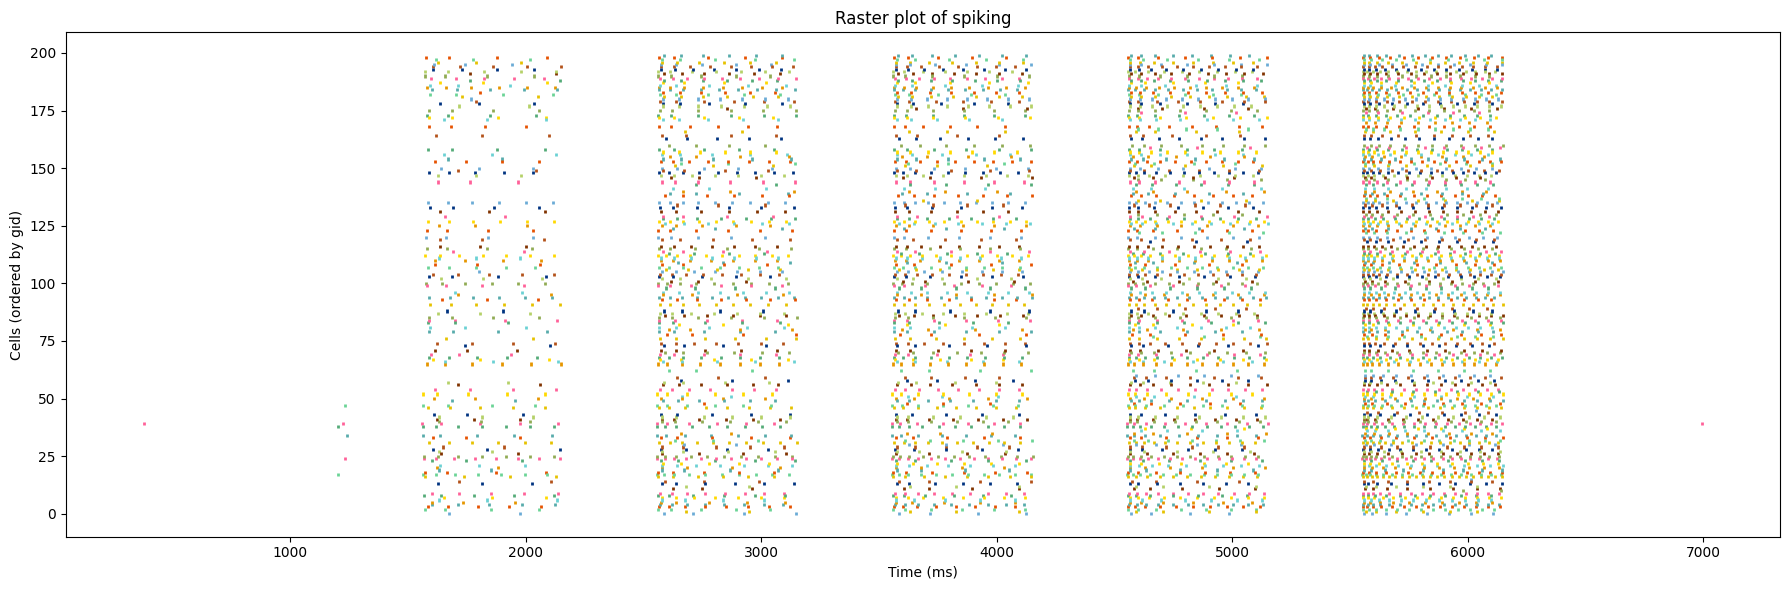

In [23]:
sim.analysis.plotRaster(timeRange=[0,7500], figSize=(18,6), popRates=False, labels = None);

Plotting recorded cell traces ... trace


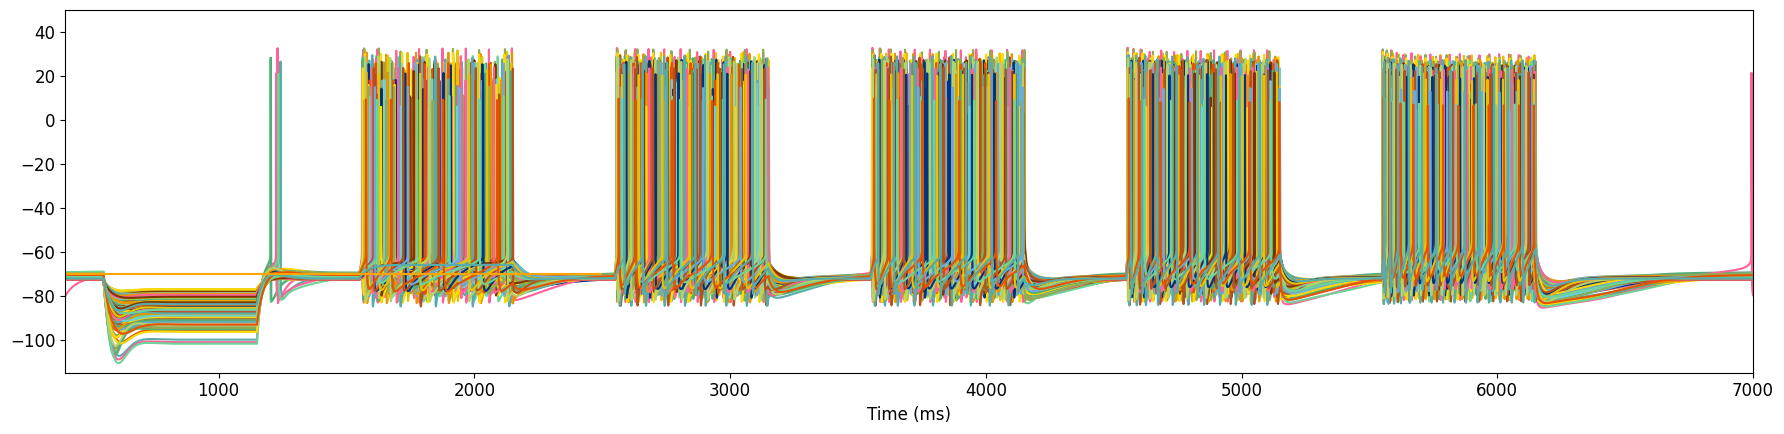

In [24]:
sim.analysis.plotTraces(include= [ii for ii in range(0,200)], timeRange=[400,7000], ylim=[-115, 50], axis=True, subtitles=False, legend=False, overlay=True, oneFigPer='trace', figSize=(18,4.5), showFig=False)
plt.hlines(xmin=0, xmax=2500, y=[-70], colors=['orange'])
plt.show()

Plotting recorded cell traces ... trace


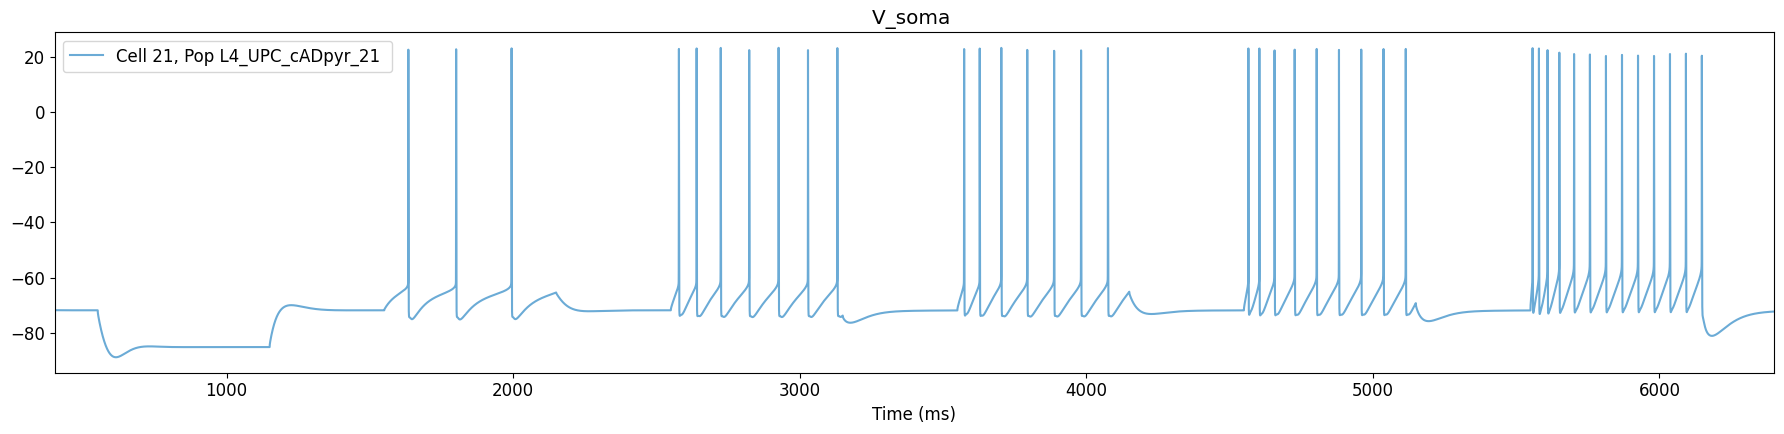

In [25]:
sim.analysis.plotTraces(include= [ii for ii in range(21,22)], timeRange=[400,6400], axis=True, overlay=True, oneFigPer='trace', figSize=(18,4.5)); #, ylim=[-80, -74]

In [26]:
    # for i,current1 in enumerate([-0.100, -0.060, 0.060, 0.070, 0.100, 0.200, current1+holding_current1, current1, 0.010, -0.100]):
    #     netParams.stimSourceParams['Input_'+str(gid)+'_'+str(i)] = {'type': 'IClamp', 'del': 550.0 + i*1000.0, 'dur': 600.0, 'amp': current1}
    #     netParams.stimTargetParams['Input->'+str(gid)+'_'+str(i)] = {'source': 'Input_'+str(gid)+'_'+str(i), 'sec':'soma_0', 'loc': 0.5, 'conds': {'pop':popName1}}

Plotting recorded cell traces ... trace


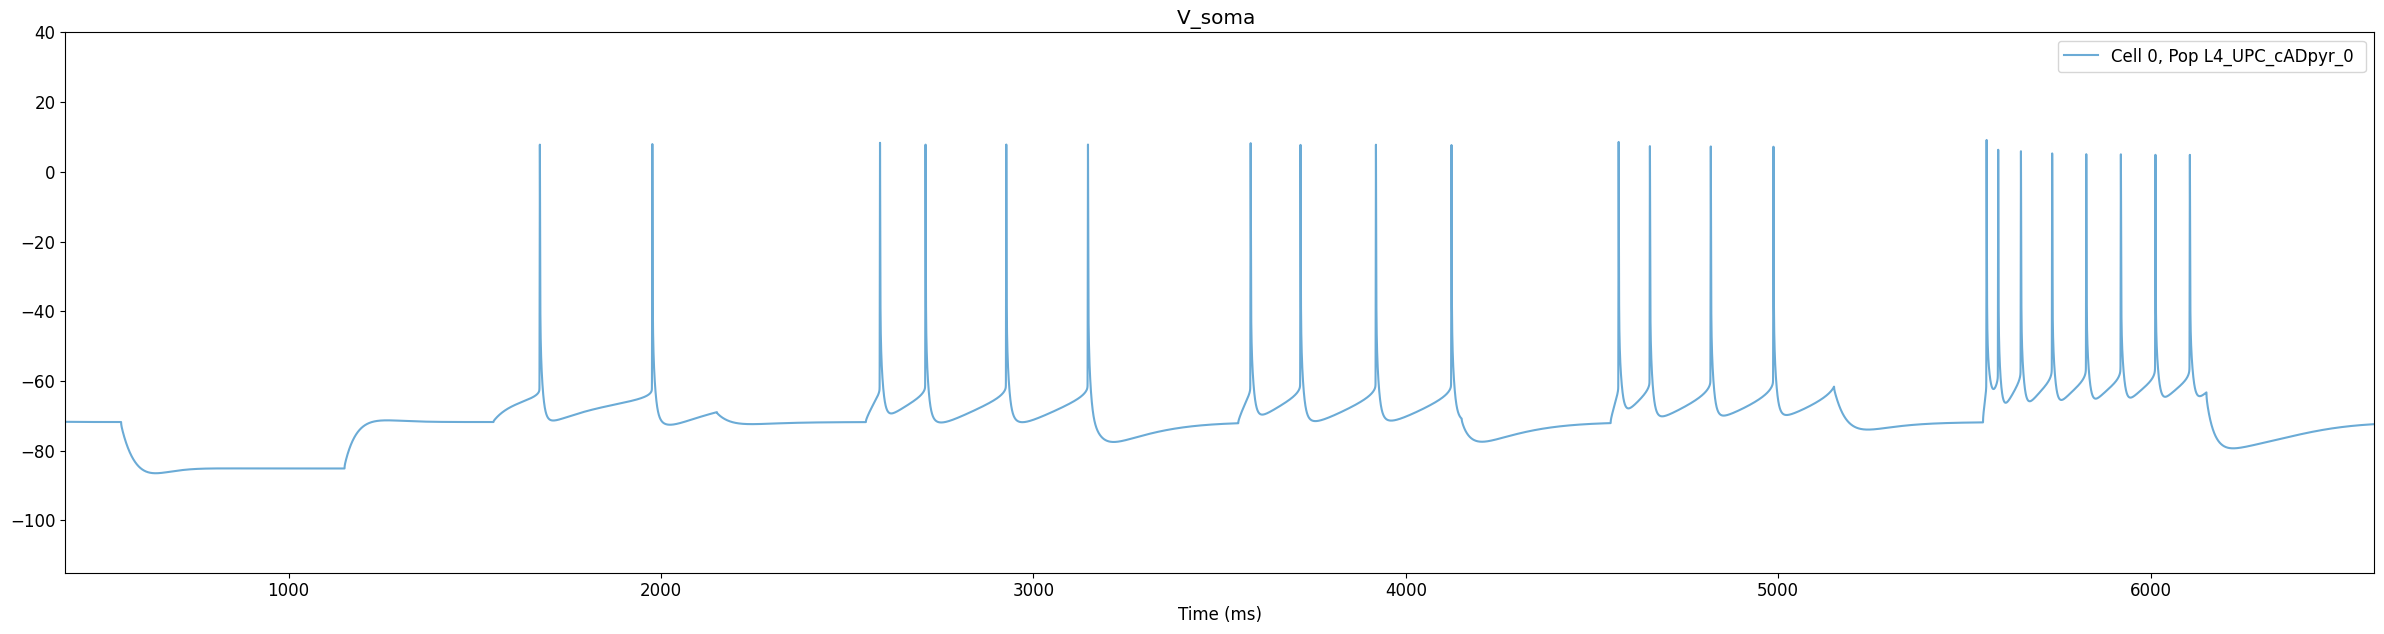

In [27]:
sim.analysis.plotTraces(include= [ii for ii in range(0,1)], timeRange=[400,6600], ylim=[-115, 40], axis=True, overlay=True, oneFigPer='trace', figSize=(24,6.5));

# Load recordings

In [28]:
# pip install openpyxl

In [29]:
import pandas as pd

excel_file_path = "Spike_trains_steps_L4_elife_Aric.xlsx"

df_rs = pd.read_excel(excel_file_path, sheet_name="RS")
df_fs = pd.read_excel(excel_file_path, sheet_name="FS")
df_rip = pd.read_excel(excel_file_path, sheet_name="Ripplets")

print("DataFrame for sheet 'RS':")
print(df_rs.head())
print("\nDataFrame for sheet 'FS':")
print(df_fs.head())
print("\nDataFrame for sheet 'Ripplets':")
print(df_rip.head())

DataFrame for sheet 'RS':
     ms    -100      60      70     100     200
0  0.00 -71.045 -70.778 -69.588 -71.480 -70.015
1  0.05 -71.060 -70.686 -69.626 -71.648 -70.061
2  0.10 -71.037 -70.587 -69.618 -71.510 -70.007
3  0.15 -71.091 -70.686 -69.649 -71.503 -69.984
4  0.20 -71.053 -70.625 -69.687 -71.617 -70.061

DataFrame for sheet 'FS':
     ms    -320     240     280     400     600
0  0.00 -68.466 -68.558 -68.886 -69.473 -69.489
1  0.05 -68.390 -68.687 -68.848 -69.450 -69.427
2  0.10 -68.336 -68.703 -68.802 -69.550 -69.359
3  0.15 -68.466 -68.695 -68.871 -69.389 -69.328
4  0.20 -68.474 -68.550 -68.932 -69.679 -69.427

DataFrame for sheet 'Ripplets':
   031820_DFI_P41  FS 5 ms stim  Field  102920_DFI_P36  RS 2 ms stim  Field.1
0            0.00       -66.475 -0.004            0.00       -65.420   -0.046
1            0.05       -66.322 -0.011            0.05       -65.404    0.010
2            0.10       -66.269  0.011            0.10       -65.414    0.074
3            0.15       -6

In [30]:
import matplotlib.pyplot as plt

(0.0, 800.0)

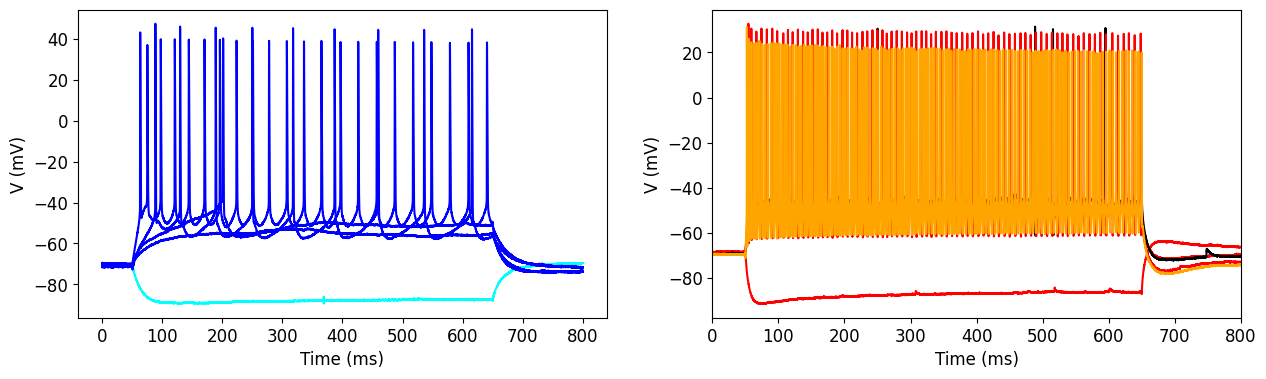

In [31]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 2, 1)
plt.plot(df_rs['ms'], df_rs[-100], color='cyan')
plt.plot(df_rs['ms'], df_rs[60], color='blue')
plt.plot(df_rs['ms'], df_rs[70], color='blue')
plt.plot(df_rs['ms'], df_rs[100], color='blue')
plt.plot(df_rs['ms'], df_rs[200], color='blue')
plt.ylabel('V (mV)')
plt.xlabel('Time (ms)')
# plt.xlim(0, 50)
# plt.ylim(-72, -69)

plt.subplot(1, 2, 2)
plt.plot(df_fs['ms'], df_fs[-320], color='red')
plt.plot(df_fs['ms'], df_fs[240], color='red')
plt.plot(df_fs['ms'], df_fs[280], color='black')
plt.plot(df_fs['ms'], df_fs[400], color='red')
plt.plot(df_fs['ms'], df_fs[600], color='orange')
# plt.title('FS with 200 pA step current')
# plt.plot(df_rs['ms'], list(sim.simData['V_soma']['cell_4'])[10000:10000+len(df_rs['ms'])])
# plt.plot(df_rs['ms'], list(sim.simData['V_soma']['cell_5'])[10000:10000+len(df_rs['ms'])])
plt.ylabel('V (mV)')
plt.xlabel('Time (ms)')
plt.xlim(0, 800)
# plt.ylim(-80, -65)
# plt.xlim(0, 50)
# plt.ylim(-70, -68)

## Compare Resistence (100 < R_Mohm > 300) (Delta V)

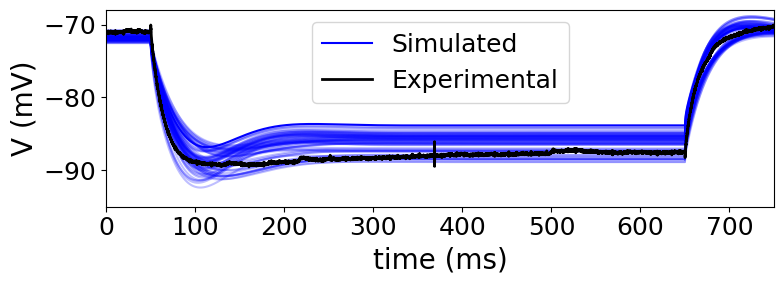

In [78]:
plt.figure(figsize=(8, 3))
# plt.figure(figsize=(24, 72))

# plt.subplot(10, 1, 1)
# plt.plot(df_rs['ms'], df_rs[-100].values, color='cyan')
# plt.plot(df_rs['ms'], df_rs[60])
# plt.plot(df_rs['ms'], df_rs[70])
# plt.plot(df_rs['ms'], df_rs[100])
# plt.plot(df_rs['ms'], df_rs[200])
# plt.title('RS with 200 pA step current')
plt.ylabel('V (mV)')
plt.xlim(0, 750)
ii = 0
cell_i_good = []
for i in range(1, 201):
    if np.min(np.array(sim.simData['V_soma']['cell_'+str(i-1)])[10000:10000+len(df_rs['ms'])]-sim.simData['V_soma']['cell_'+str(i-1)][10000]) < -15 and np.min(np.array(sim.simData['V_soma']['cell_'+str(i-1)])[10000:10000+len(df_rs['ms'])]-sim.simData['V_soma']['cell_'+str(i-1)][10000]) > -20:
    
    # sim.simData['V_soma']['cell_'+str(i-1)][20000]-sim.simData['V_soma']['cell_'+str(i-1)][10000] < -12 and \
    # sim.simData['V_soma']['cell_'+str(i-1)][11800]-sim.simData['V_soma']['cell_'+str(i-1)][10000] < -12:
        cell_i_good.append(i)
        ii = ii + 1
        # plt.subplot(30, 1, ii)
        plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(i-1)])[10000:10000+len(df_rs['ms'])], color='blue', alpha=0.25)
        # plt.plot(df_rs['ms'], df_rs[-100].values, color='cyan')
        # plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(i-1)])[10000+120000:10000+120000+len(df_rs['ms'])]-sim.simData['V_soma']['cell_'+str(i-1)][10000+120000])
        plt.ylabel('V (mV)')
        plt.xlim(0, 750)
        plt.ylim(-95, -68)


plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(i-1)])[10000:10000+len(df_rs['ms'])], color='blue', alpha=1.0, label='Simulated')
plt.plot(df_rs['ms'], df_rs[-100].values, linewidth = 2.0, color='black', label='Experimental')
plt.ylabel('V (mV)', fontsize=20)
plt.xlabel('time (ms)', fontsize=20)
plt.xlim(0, 750)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(False)
plt.legend(fontsize=18)
plt.tight_layout()
plt.savefig('Fig4D_L4_RS_step_current-100pA.png', dpi=300)

# plt.show()

In [33]:
df_rs

,ms,-100,60,70,100,200
0,0.00,-71.045,-70.778,-69.588,-71.480,-70.015
1,0.05,-71.060,-70.686,-69.626,-71.648,-70.061
2,0.10,-71.037,-70.587,-69.618,-71.510,-70.007
3,0.15,-71.091,-70.686,-69.649,-71.503,-69.984
4,0.20,-71.053,-70.625,-69.687,-71.617,-70.061
...,...,...,...,...,...,...
15996,799.80,-69.511,-71.831,-71.632,-73.814,-73.402
15997,799.85,-69.611,-72.090,-71.617,-73.883,-73.288
15998,799.90,-69.679,-71.983,-71.671,-73.708,-73.151
15999,799.95,-69.725,-71.831,-71.754,-73.784,-73.196


In [34]:
len(cell_i_good)

68

In [35]:
I = -100

mask_step = (df_rs['ms'] >= 150) & (df_rs['ms'] <= 500)

mask_rest = (df_rs['ms'] >= 0) & (df_rs['ms'] <= 50)

V_step_exp = df_rs[-100][mask_step].mean()
V_rest_exp = df_rs[-100][mask_rest].mean()
delta_V_exp = V_step_exp - V_rest_exp 
Rin_exp = delta_V_exp / I  


print(f'Resistência da célula experimental: {Rin_exp:.2f}')

Resistência da célula experimental: 0.17


In [36]:
len(cell_i_good)

68

## Compare 1st spike time at 100 pA

(40.0, 150.0)

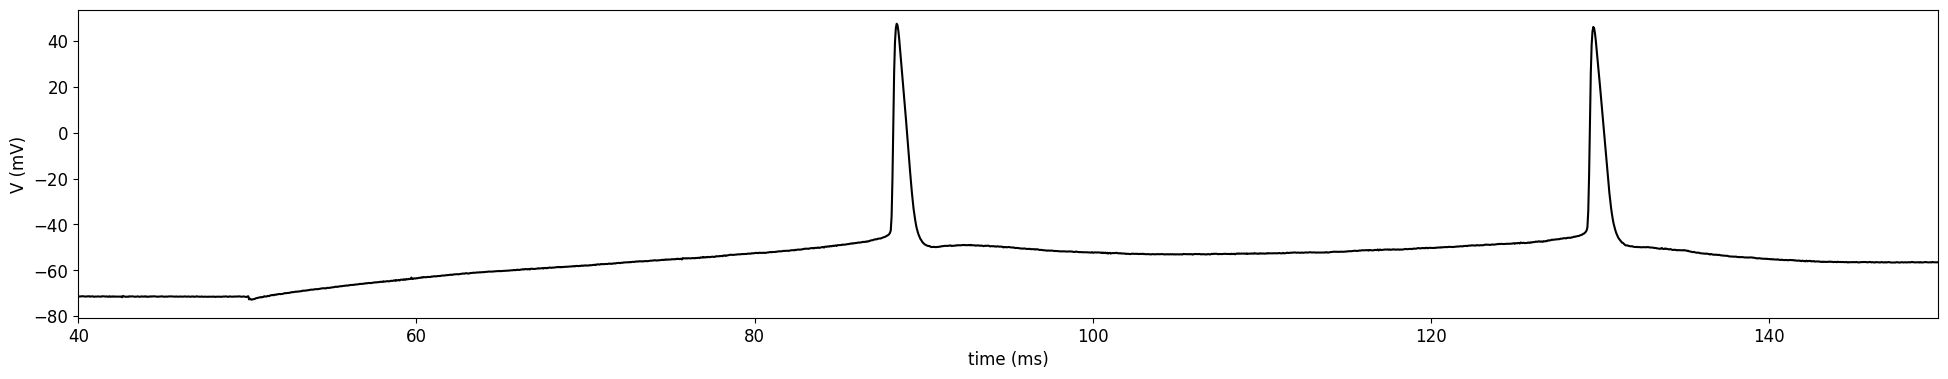

In [37]:
# plt.figure(figsize=(24, 72))
plt.figure(figsize=(24, 4))
plt.ylabel('V (mV)')
plt.xlim(0, 750)
for ii,i in enumerate(cell_i_good):
    if np.max(np.array(sim.simData['V_soma']['cell_'+str(i-1)])[4*20000+10000:4*20000+10000+1600]) < -50:
        # plt.subplot(30, 1, ii+1)
        plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(i-1)])[4*20000+10000:4*20000+10000+len(df_rs['ms'])], color='blue',alpha = 0.15)
        # plt.plot(df_rs['ms'], df_rs[60].values, color='cyan')
        # plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(i-1)])[10000+120000:10000+120000+len(df_rs['ms'])]-sim.simData['V_soma']['cell_'+str(i-1)][10000+120000])
        plt.ylabel('V (mV)')
        plt.xlim(40, 150)
        # plt.xlim(0, 750)
        plt.ylim(-85, 50)

plt.plot(df_rs['ms'], df_rs[100].values, color='black')
plt.ylabel('V (mV)')
plt.xlabel('time (ms)')
plt.xlim(0, 750)
plt.xlim(40, 150)

## Compare number of spikes for 100 pA

In [38]:
len(cell_i_good)

68

(0.0, 750.0)

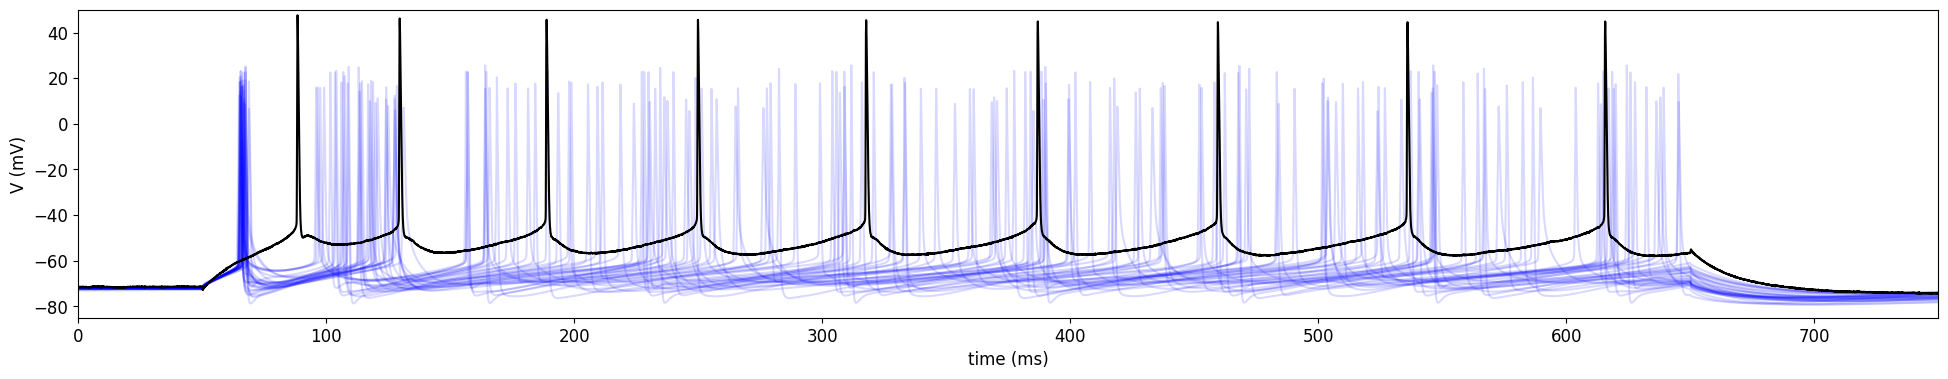

In [39]:
# plt.figure(figsize=(24, 72))
plt.figure(figsize=(24, 4))
plt.ylabel('V (mV)')
plt.xlim(0, 750)
for ii,i in enumerate(cell_i_good):
    if np.max(np.array(sim.simData['V_soma']['cell_'+str(i-1)])[4*20000+10000+1300:4*20000+10000+1500]) > 0:
        # plt.subplot(30, 1, ii+1)
        plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(i-1)])[4*20000+10000:4*20000+10000+len(df_rs['ms'])], color='blue',alpha = 0.15)
        # plt.plot(df_rs['ms'], df_rs[60].values, color='cyan')
        # plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(i-1)])[10000+120000:10000+120000+len(df_rs['ms'])]-sim.simData['V_soma']['cell_'+str(i-1)][10000+120000])
        plt.ylabel('V (mV)')
        # plt.xlim(40, 150)
        plt.xlim(0, 750)
        plt.ylim(-85, 50)

plt.plot(df_rs['ms'], df_rs[100].values, color='black')
plt.ylabel('V (mV)')
plt.xlabel('time (ms)')
plt.xlim(0, 750)
# plt.xlim(40, 150)

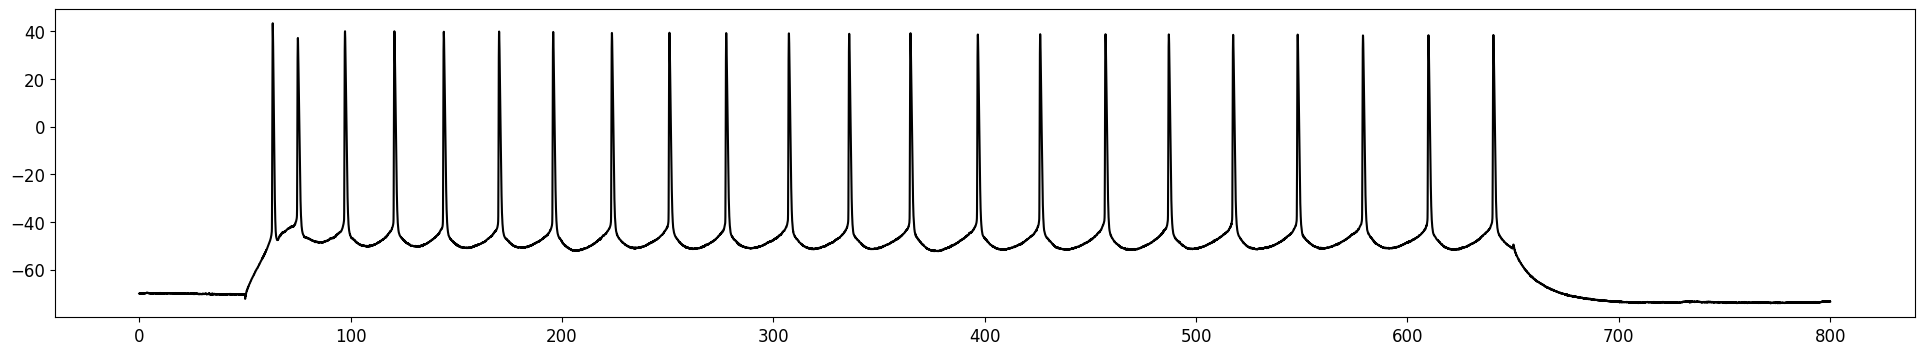

In [108]:
plt.figure(figsize=(24, 4))
plt.plot(df_rs['ms'], df_rs[200].values, color='black')

In [115]:
Firing = sim.analysis.calculateRate(timeRange=[4550,5150])
Firing2 = sim.analysis.calculateRate(timeRange=[5550,6150])
freq100 = []
freq200 = []
cell_names = []
FR_RS_100pA = 9/0.600
FR_RS_200pA = 22/0.600
print('%s \t= \t%.2f Hz \t %.2f Hz' % ("RS exp 100 and 200pA", FR_RS_100pA, FR_RS_200pA))
for i, pop in enumerate(Firing[0]):
    if abs(FR_RS_100pA - Firing[1][i]) < 7.5 and i in cell_i_good:
        print('%s \t= \t%.2f Hz \t %.2f Hz' % (pop, Firing[1][i], Firing2[1][i]))
        freq100.append(Firing[1][i])
        freq200.append(Firing2[1][i])
        cell_names.append(pop)
        
# Firing[1]

Calculating avg and peak firing rates ...
Calculating avg and peak firing rates ...
RS exp 100 and 200pA 	= 	15.00 Hz 	 36.67 Hz
L4_UPC_cADpyr_4 	= 	18.33 Hz 	 25.00 Hz
L4_UPC_cADpyr_5 	= 	10.00 Hz 	 16.67 Hz
L4_UPC_cADpyr_6 	= 	11.67 Hz 	 20.00 Hz
L4_UPC_cADpyr_7 	= 	16.67 Hz 	 23.33 Hz
L4_UPC_cADpyr_9 	= 	18.33 Hz 	 25.00 Hz
L4_UPC_cADpyr_13 	= 	11.67 Hz 	 18.33 Hz
L4_UPC_cADpyr_19 	= 	8.33 Hz 	 15.00 Hz
L4_UPC_cADpyr_20 	= 	10.00 Hz 	 18.33 Hz
L4_UPC_cADpyr_21 	= 	15.00 Hz 	 21.67 Hz
L4_UPC_cADpyr_22 	= 	11.67 Hz 	 18.33 Hz
L4_UPC_cADpyr_23 	= 	10.00 Hz 	 16.67 Hz
L4_UPC_cADpyr_26 	= 	10.00 Hz 	 20.00 Hz
L4_UPC_cADpyr_27 	= 	8.33 Hz 	 15.00 Hz
L4_UPC_cADpyr_29 	= 	10.00 Hz 	 16.67 Hz
L4_UPC_cADpyr_31 	= 	20.00 Hz 	 28.33 Hz
L4_UPC_cADpyr_33 	= 	10.00 Hz 	 16.67 Hz
L4_UPC_cADpyr_40 	= 	13.33 Hz 	 18.33 Hz
L4_UPC_cADpyr_41 	= 	13.33 Hz 	 18.33 Hz
L4_UPC_cADpyr_42 	= 	13.33 Hz 	 18.33 Hz
L4_UPC_cADpyr_43 	= 	10.00 Hz 	 16.67 Hz
L4_UPC_cADpyr_49 	= 	15.00 Hz 	 21.67 Hz
L4_UPC_cADpyr_50 

In [41]:
cells_15hz = []
for i, pop in enumerate(Firing[0]):
    if Firing[1][i] == 15.0 and i in cell_i_good:
        cells_15hz.append(pop)

print("Cells with firing frequency = 15 Hz:", cells_15hz)

Cells with firing frequency = 15 Hz: ['L4_UPC_cADpyr_21', 'L4_UPC_cADpyr_49', 'L4_TPC_cADpyr_56', 'L4_TPC_cADpyr_87', 'L4_TPC_cADpyr_93', 'L4_TPC_cADpyr_128', 'L4_TPC_cADpyr_147', 'L4_SSC_cADpyr_183', 'L4_SSC_cADpyr_193']


In [44]:
import numpy as np


time = np.arange(0, sim.cfg.duration + sim.cfg.dt, sim.cfg.dt)


index_450ms = np.argmin(np.abs(time - 450))
index_1000ms = np.argmin(np.abs(time - 1000))

print(f"Tempo mais próximo para 450ms: {time[index_450ms]:.2f} ms")
print(f"Tempo mais próximo para 1000ms: {time[index_1000ms]:.2f} ms")
print("\nVoltagens da Soma para Células Selecionadas:")

cell_voltages = {}

for cell_full_name in cell_names:
    try:
        gid = cell_full_name.split('_')[-1]
        cell_name_key = f"cell_{gid}" 

        if cell_name_key in sim.simData['V_soma']:
            soma_voltage_trace = sim.simData['V_soma'][cell_name_key]
            
            if index_1000ms < len(soma_voltage_trace):
                voltage_450ms = soma_voltage_trace[index_450ms]
                voltage_1000ms = soma_voltage_trace[index_1000ms]
                
                cell_voltages[cell_full_name] = { #
                    'V_450ms': voltage_450ms,
                    'V_1000ms': voltage_1000ms
                }
                print(f"{cell_full_name}: V_soma aos 450 ms = {voltage_450ms:.2f} mV, V_soma aos 1000 ms = {voltage_1000ms:.2f} mV")
            else:
                print(f"Aviso: O trace de voltagem para {cell_full_name} ({cell_name_key}) é muito curto para acessar 1000 ms.")
        else:
            print(f"Aviso: Dados de V_soma não encontrados para a chave: {cell_name_key} (original: {cell_full_name})")
    except Exception as e:
        print(f"Erro ao processar a célula {cell_full_name}: {e}")


Tempo mais próximo para 450ms: 450.00 ms
Tempo mais próximo para 1000ms: 1000.00 ms

Voltagens da Soma para Células Selecionadas:
L4_UPC_cADpyr_4: V_soma aos 450 ms = -71.71 mV, V_soma aos 1000 ms = -86.53 mV
L4_UPC_cADpyr_5: V_soma aos 450 ms = -71.26 mV, V_soma aos 1000 ms = -87.94 mV
L4_UPC_cADpyr_6: V_soma aos 450 ms = -71.97 mV, V_soma aos 1000 ms = -87.93 mV
L4_UPC_cADpyr_7: V_soma aos 450 ms = -72.04 mV, V_soma aos 1000 ms = -84.88 mV
L4_UPC_cADpyr_9: V_soma aos 450 ms = -71.72 mV, V_soma aos 1000 ms = -86.41 mV
L4_UPC_cADpyr_13: V_soma aos 450 ms = -72.11 mV, V_soma aos 1000 ms = -85.19 mV
L4_UPC_cADpyr_19: V_soma aos 450 ms = -71.66 mV, V_soma aos 1000 ms = -86.36 mV
L4_UPC_cADpyr_20: V_soma aos 450 ms = -72.07 mV, V_soma aos 1000 ms = -88.85 mV
L4_UPC_cADpyr_21: V_soma aos 450 ms = -71.90 mV, V_soma aos 1000 ms = -85.26 mV
L4_UPC_cADpyr_22: V_soma aos 450 ms = -72.32 mV, V_soma aos 1000 ms = -85.27 mV
L4_UPC_cADpyr_23: V_soma aos 450 ms = -71.40 mV, V_soma aos 1000 ms = -88.4

In [45]:
I = 100 #pA
membrane_resistances = []

for cell_full_name, voltages in cell_voltages.items():
    delta_V = voltages['V_450ms'] - voltages['V_1000ms']
    
    Rm = (delta_V / I) * 1000
    membrane_resistances.append(Rm)


    print(f"{cell_full_name}: ΔV = {delta_V:.2f} mV, Rm = {Rm:.2f}")


L4_UPC_cADpyr_4: ΔV = 14.83 mV, Rm = 148.28
L4_UPC_cADpyr_5: ΔV = 16.68 mV, Rm = 166.81
L4_UPC_cADpyr_6: ΔV = 15.96 mV, Rm = 159.57
L4_UPC_cADpyr_7: ΔV = 12.84 mV, Rm = 128.40
L4_UPC_cADpyr_9: ΔV = 14.69 mV, Rm = 146.86
L4_UPC_cADpyr_13: ΔV = 13.08 mV, Rm = 130.81
L4_UPC_cADpyr_19: ΔV = 14.70 mV, Rm = 146.96
L4_UPC_cADpyr_20: ΔV = 16.78 mV, Rm = 167.77
L4_UPC_cADpyr_21: ΔV = 13.37 mV, Rm = 133.65
L4_UPC_cADpyr_22: ΔV = 12.95 mV, Rm = 129.47
L4_UPC_cADpyr_23: ΔV = 17.06 mV, Rm = 170.62
L4_UPC_cADpyr_26: ΔV = 12.85 mV, Rm = 128.52
L4_UPC_cADpyr_27: ΔV = 14.34 mV, Rm = 143.36
L4_UPC_cADpyr_29: ΔV = 13.38 mV, Rm = 133.76
L4_UPC_cADpyr_31: ΔV = 15.11 mV, Rm = 151.10
L4_UPC_cADpyr_33: ΔV = 15.98 mV, Rm = 159.78
L4_UPC_cADpyr_40: ΔV = 12.81 mV, Rm = 128.05
L4_UPC_cADpyr_41: ΔV = 13.08 mV, Rm = 130.84
L4_UPC_cADpyr_42: ΔV = 12.91 mV, Rm = 129.06
L4_UPC_cADpyr_43: ΔV = 15.46 mV, Rm = 154.55
L4_UPC_cADpyr_49: ΔV = 11.94 mV, Rm = 119.38
L4_UPC_cADpyr_50: ΔV = 16.71 mV, Rm = 167.13
L4_TPC_cADpyr_5

In [46]:
print(list(sim.simData['V_soma'].keys())[:10]) 

['cell_0', 'cell_1', 'cell_2', 'cell_3', 'cell_4', 'cell_5', 'cell_6', 'cell_7', 'cell_8', 'cell_9']


In [47]:
from scipy.signal import find_peaks

def measure_spike_width_half_height(trace, time, threshold=-40):
    """
    Measures the spike width at half-height (SWHH) for a single voltage trace.
    Returns a list of SWHH values (ms) for all spikes detected above threshold.
    """
    trace = np.array(trace)
    time = np.array(time)
    swhh_list = []

    # Find all peaks above threshold

    peaks, _ = find_peaks(trace, height=threshold)
    for peak_idx in peaks:
        peak_v = trace[peak_idx]
        # Estimate baseline as the minimum before the spike (within 10 ms window)
        baseline_idx = max(0, peak_idx - int(10 / (time[1] - time[0])))
        baseline_v = np.min(trace[baseline_idx:peak_idx])
        half_height = baseline_v + 0.5 * (peak_v - baseline_v)

        # Find left crossing
        left = peak_idx
        while left > 0 and trace[left] > half_height:
            left -= 1
        # Linear interpolation for more accurate crossing
        if left < peak_idx and trace[left+1] != trace[left]:
            t_left = time[left] + (half_height - trace[left]) * (time[left+1] - time[left]) / (trace[left+1] - trace[left])
        else:
            t_left = time[left]

        # Find right crossing
        right = peak_idx
        while right < len(trace)-1 and trace[right] > half_height:
            right += 1
        if right > peak_idx and trace[right-1] != trace[right]:
            t_right = time[right-1] + (half_height - trace[right-1]) * (time[right] - time[right-1]) / (trace[right] - trace[right-1])
        else:
            t_right = time[right]

        swhh = t_right - t_left
        swhh_list.append(swhh)

    return swhh_list

# Calculate SWHH for each cell in freq100
swhh_results = {}
for cell_full_name in cell_names:
    gid = cell_full_name.split('_')[-1]
    cell_key = f"cell_{gid}"
    if cell_key in sim.simData['V_soma']:
        trace = np.array(sim.simData['V_soma'][cell_key])
        swhh_list = measure_spike_width_half_height(trace, time)
        swhh_results[cell_full_name] = swhh_list

# Print mean SWHH for each cell
for cell, swhh_list in swhh_results.items():
    if swhh_list:
        print(f"{cell}: mean SWHH = {np.mean(swhh_list):.2f} ms, n_spikes = {len(swhh_list)}")
    else:
        print(f"{cell}: no spikes detected above threshold")

L4_UPC_cADpyr_4: mean SWHH = 0.64 ms, n_spikes = 48
L4_UPC_cADpyr_5: mean SWHH = 1.06 ms, n_spikes = 29
L4_UPC_cADpyr_6: mean SWHH = 0.77 ms, n_spikes = 31
L4_UPC_cADpyr_7: mean SWHH = 0.65 ms, n_spikes = 42
L4_UPC_cADpyr_9: mean SWHH = 0.64 ms, n_spikes = 48
L4_UPC_cADpyr_13: mean SWHH = 0.87 ms, n_spikes = 33
L4_UPC_cADpyr_19: mean SWHH = 1.37 ms, n_spikes = 24
L4_UPC_cADpyr_20: mean SWHH = 1.01 ms, n_spikes = 27
L4_UPC_cADpyr_21: mean SWHH = 0.68 ms, n_spikes = 39
L4_UPC_cADpyr_22: mean SWHH = 0.65 ms, n_spikes = 29
L4_UPC_cADpyr_23: mean SWHH = 1.00 ms, n_spikes = 29
L4_UPC_cADpyr_26: mean SWHH = 0.87 ms, n_spikes = 28
L4_UPC_cADpyr_27: mean SWHH = 1.31 ms, n_spikes = 24
L4_UPC_cADpyr_29: mean SWHH = 0.81 ms, n_spikes = 28
L4_UPC_cADpyr_31: mean SWHH = 0.65 ms, n_spikes = 55
L4_UPC_cADpyr_33: mean SWHH = 1.11 ms, n_spikes = 29
L4_UPC_cADpyr_40: mean SWHH = 0.87 ms, n_spikes = 34
L4_UPC_cADpyr_41: mean SWHH = 0.88 ms, n_spikes = 35
L4_UPC_cADpyr_42: mean SWHH = 0.87 ms, n_spikes = 3

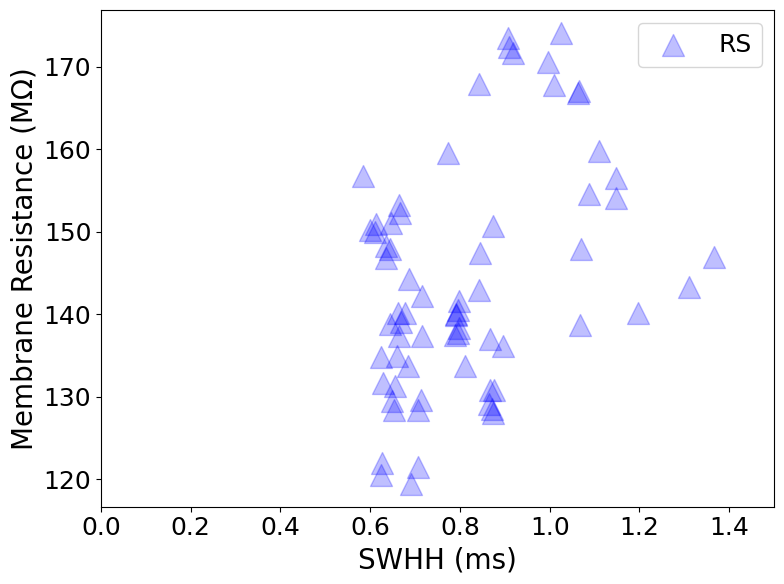

In [124]:
# Calculate mean SWHH for each cell in freq100
mean_swhh = []
for cell in cell_names:
    swhh = swhh_results.get(cell, [])
    if swhh:
        mean_swhh.append(np.mean(swhh))
    else:
        mean_swhh.append(np.nan)

plt.figure(figsize=(8, 6))
plt.scatter(mean_swhh, membrane_resistances, marker='^', s=250, alpha=0.25, color='blue', edgecolors='b', label='RS')
plt.xlabel('SWHH (ms)', fontsize=20)
plt.xlim(0, 1.5)
plt.ylabel('Membrane Resistance (MΩ)', fontsize=20)
# plt.title('Membrane Resistance vs. Mean SWHH', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(False)
plt.legend(fontsize=18)
plt.tight_layout()
# plt.savefig('Fig_SWHH_L4_RS_step_100pA.png', dpi=300)


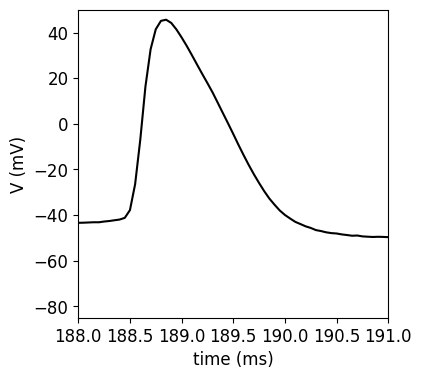

In [102]:
plt.figure(figsize=(4, 4))
plt.plot(df_rs['ms'], df_rs[100].values, color='black')
plt.ylabel('V (mV)')
plt.xlim(188, 191)
plt.ylim(-85, 50)
plt.ylabel('V (mV)')
plt.xlabel('time (ms)');

In [49]:
print(f"Number of cells with 15 Hz firing frequency: {len(cells_15hz)}")
print("Cells:", cells_15hz)


Number of cells with 15 Hz firing frequency: 9
Cells: ['L4_UPC_cADpyr_21', 'L4_UPC_cADpyr_49', 'L4_TPC_cADpyr_56', 'L4_TPC_cADpyr_87', 'L4_TPC_cADpyr_93', 'L4_TPC_cADpyr_128', 'L4_TPC_cADpyr_147', 'L4_SSC_cADpyr_183', 'L4_SSC_cADpyr_193']


In [50]:
# Find the gid for the cell 'L4_UPC_cADpyr_21'
for gid, name in cellName_list.items():
    if name.startswith('L4_TPC_cADpyr_56'):
        print(f"GID for L4_TPC_cADpyr_56: {gid}")
        break

GID for L4_TPC_cADpyr_56: 118551


In [51]:
gid = 112501

hoc_file = nodesinfo['model_template'][gid][4:] + '.hoc'
morphology_file = nodesinfo['morphology'][gid] + '.asc'

print("Hoc file:", hoc_file)
print("Morphology file:", morphology_file)

Hoc file: cADpyr_L4UPC.hoc
Morphology file: dend-rp120608_P_3_idB_axon-rp120521_P_1_idC_-_Scale_x1.000_y0.950_z1.000.asc


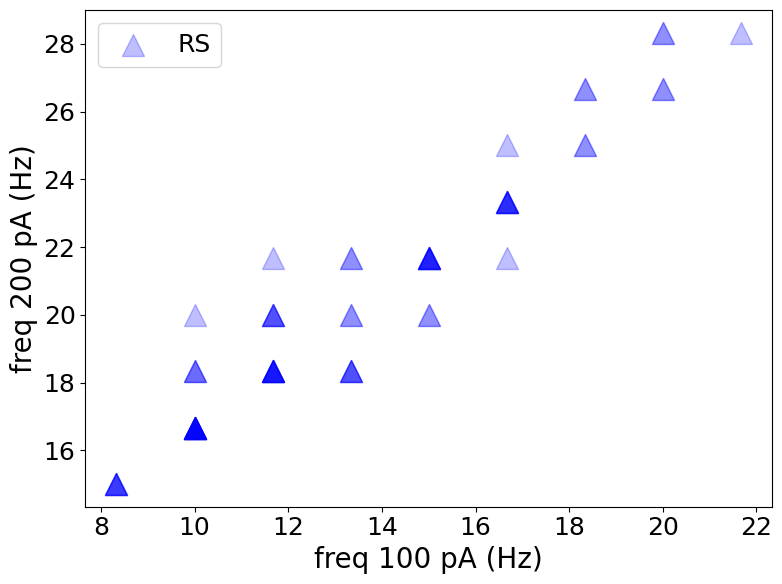

In [117]:
plt.figure(figsize=(8, 6))
plt.scatter(freq100, freq200, marker='^', s=250, alpha=0.25, color='blue', edgecolors='b', label='RS')
plt.xlabel('freq 100 pA (Hz)', fontsize=20)
# plt.xlim(0, 1.5)
plt.ylabel('freq 200 pA (Hz)', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(False)
plt.legend(fontsize=18)
plt.tight_layout()
# plt.savefig('Fig_FR_L4_RS_step_100_200pA.png', dpi=300)

In [ ]:
# data_to_save = {
#     "mean_swhh": list(mean_swhh),
#     "membrane_resistances": list(membrane_resistances),
#     "freq100": list(freq100),
#     "freq200": list(freq200)
# }

# with open("summary_metrics_RS_simuled.json", "w") as f:
#     json.dump(data_to_save, f, indent=2)

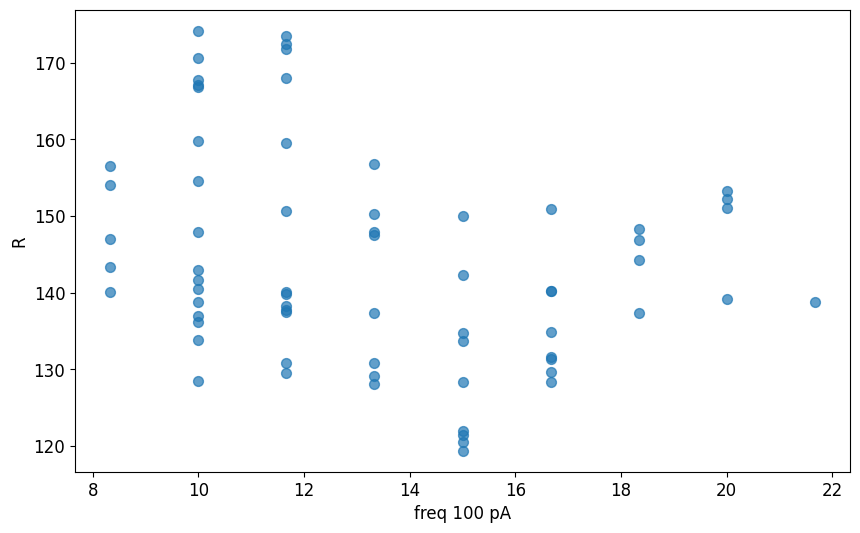

In [52]:
plt.figure(figsize=(10, 6)) 
plt.scatter(freq100, membrane_resistances, s=50, alpha=0.7)
plt.ylabel('R')
plt.xlabel('freq 100 pA')

plt.grid(False)

plt.show()

In [ ]:
plt.figure(figsize=(8, 30))
plt.ylabel('V (mV)')
plt.xlim(0, 750)
for ii, cell_full_name in enumerate(cells_15hz):
    cell_gid = cell_full_name.split('_')[-1]
    cell_key = f'cell_{cell_gid}'
    if cell_key in sim.simData['V_soma']:
        trace = sim.simData['V_soma'][cell_key]
        plt.subplot(len(cells_15hz), 1, ii+1)
        plt.plot(df_rs['ms'], np.array(trace)[5*20000+10000:5*20000+10000+len(df_rs['ms'])], color='blue')
        # plt.plot(df_rs['ms'], df_rs[100].values, color='black')
        plt.ylabel('V (mV)')
        plt.xlim(0, 750)
        plt.ylim(-85, 50)

plt.ylabel('V (mV)')
plt.xlabel('time (ms)')
plt.xlim(0, 750)
# plt.xlim(40, 150)

(0.0, 750.0)

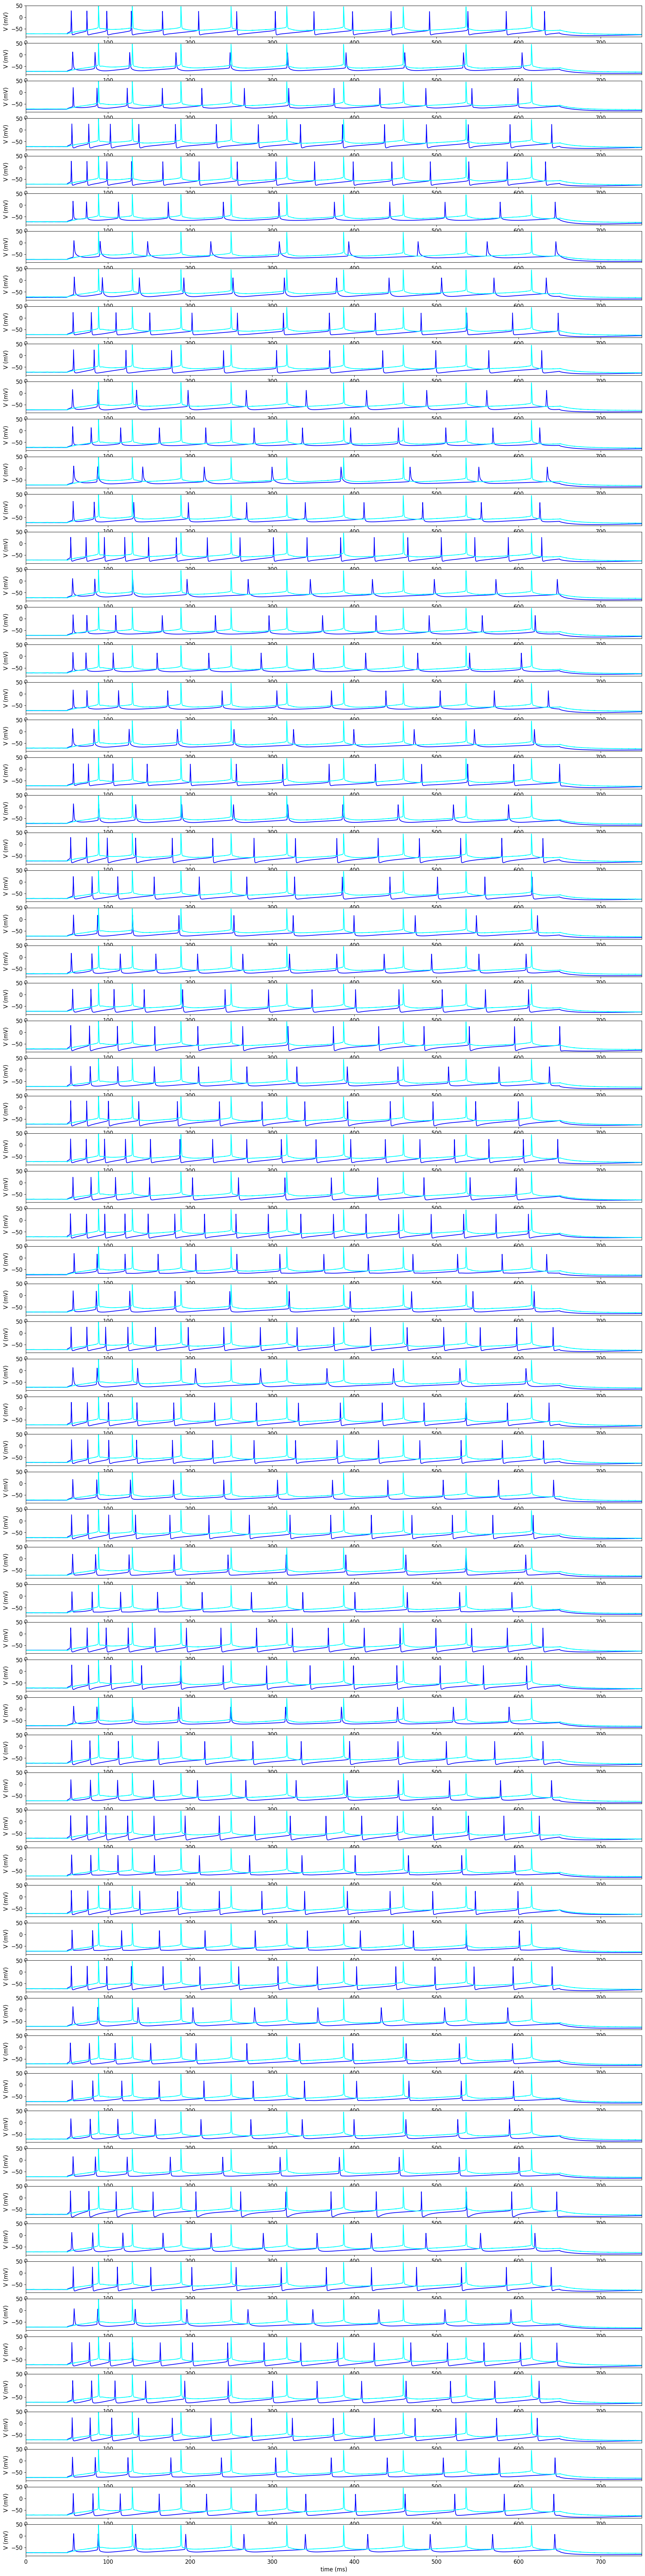

In [54]:
plt.figure(figsize=(24, 100))
plt.ylabel('V (mV)')
plt.xlim(0, 750)
for ii, cell_full_name in enumerate(cell_names):
    cell_gid = cell_full_name.split('_')[-1]
    cell_key = f'cell_{cell_gid}'
    if cell_key in sim.simData['V_soma']:
        trace = sim.simData['V_soma'][cell_key]
        plt.subplot(len(cell_names), 1, ii+1)
        plt.plot(df_rs['ms'], np.array(trace)[5*20000+10000:5*20000+10000+len(df_rs['ms'])], color='blue')
        plt.plot(df_rs['ms'], df_rs[100].values, color='cyan')
        plt.ylabel('V (mV)')
        plt.xlim(0, 750)
        plt.ylim(-85, 50)

plt.ylabel('V (mV)')
plt.xlabel('time (ms)')
plt.xlim(0, 750)
# plt.xlim(40, 150)

In [55]:
for name in cell_names:
    print(name)

L4_UPC_cADpyr_4
L4_UPC_cADpyr_5
L4_UPC_cADpyr_6
L4_UPC_cADpyr_7
L4_UPC_cADpyr_9
L4_UPC_cADpyr_13
L4_UPC_cADpyr_19
L4_UPC_cADpyr_20
L4_UPC_cADpyr_21
L4_UPC_cADpyr_22
L4_UPC_cADpyr_23
L4_UPC_cADpyr_26
L4_UPC_cADpyr_27
L4_UPC_cADpyr_29
L4_UPC_cADpyr_31
L4_UPC_cADpyr_33
L4_UPC_cADpyr_40
L4_UPC_cADpyr_41
L4_UPC_cADpyr_42
L4_UPC_cADpyr_43
L4_UPC_cADpyr_49
L4_UPC_cADpyr_50
L4_TPC_cADpyr_54
L4_TPC_cADpyr_56
L4_TPC_cADpyr_66
L4_TPC_cADpyr_69
L4_TPC_cADpyr_74
L4_TPC_cADpyr_76
L4_TPC_cADpyr_85
L4_TPC_cADpyr_87
L4_TPC_cADpyr_91
L4_TPC_cADpyr_93
L4_TPC_cADpyr_94
L4_TPC_cADpyr_95
L4_TPC_cADpyr_102
L4_TPC_cADpyr_104
L4_TPC_cADpyr_108
L4_TPC_cADpyr_110
L4_TPC_cADpyr_111
L4_TPC_cADpyr_114
L4_TPC_cADpyr_116
L4_TPC_cADpyr_119
L4_TPC_cADpyr_125
L4_TPC_cADpyr_127
L4_TPC_cADpyr_128
L4_TPC_cADpyr_129
L4_TPC_cADpyr_131
L4_TPC_cADpyr_133
L4_TPC_cADpyr_135
L4_TPC_cADpyr_144
L4_TPC_cADpyr_147
L4_TPC_cADpyr_150
L4_TPC_cADpyr_153
L4_TPC_cADpyr_164
L4_TPC_cADpyr_168
L4_TPC_cADpyr_171
L4_TPC_cADpyr_175
L4_SSC_cADpyr

In [56]:
hex = 'hex0'
i = 0
for ii, gid in enumerate(node_sets['hex0']['node_id']):
    if 'L4_' in nodesinfo['mtype'][gid] and distance2Dmean(gid, mean_x, mean_y) > 0.0 and distance2Dmean(gid, mean_x, mean_y) < 25.0 and 'EXC' in nodesinfo['synapse_class'][gid]:
        i = i + 1

        print("%d \t%d %s %s %.4f %.2f %.4f %.2f" % (i,gid,nodesinfo['synapse_class'][gid],nodesinfo['mtype'][gid], 
                                                     nodesinfo['@dynamics:threshold_current'][gid],nodesinfo['@dynamics:resting_potential'][gid],
                                                     nodesinfo['@dynamics:holding_current'][gid],
                                                     nodesinfo['@dynamics:resting_potential'][gid] + nodesinfo['@dynamics:holding_current'][gid] * nodesinfo['@dynamics:input_resistance'][gid]))
                                                     

1 	109126 EXC L4_UPC 0.1281 -78.55 -0.0562 -85.71
2 	109354 EXC L4_UPC 0.0788 -76.18 -0.0505 -86.53
3 	109632 EXC L4_UPC 0.0970 -78.87 -0.0418 -85.58
4 	112531 EXC L4_UPC 0.1311 -76.17 -0.0749 -86.74
5 	112935 EXC L4_UPC 0.0928 -78.84 -0.0403 -85.56
6 	113019 EXC L4_UPC 0.0576 -77.44 -0.0304 -85.85
7 	113207 EXC L4_UPC 0.1163 -78.05 -0.0556 -85.71
8 	113680 EXC L4_UPC 0.2364 -74.86 -0.1595 -87.51
9 	114264 EXC L4_UPC 0.1887 -77.59 -0.0877 -85.66
10 	114284 EXC L4_UPC 0.2849 -75.19 -0.1723 -87.34
11 	114352 EXC L4_UPC 0.2910 -74.48 -0.1830 -86.96
12 	114599 EXC L4_UPC 0.0455 -77.41 -0.0281 -86.02
13 	115007 EXC L4_UPC 0.1212 -75.28 -0.0840 -87.59
14 	116011 EXC L4_UPC 0.2440 -78.16 -0.1042 -85.73
15 	116420 EXC L4_UPC 0.0849 -75.68 -0.0552 -86.48
16 	117199 EXC L4_UPC 0.0349 -79.38 -0.0158 -85.36
17 	118008 EXC L4_TPC 0.2137 -77.71 -0.1009 -85.74
18 	118052 EXC L4_TPC 0.0538 -79.18 -0.0232 -85.35
19 	118445 EXC L4_TPC 0.2743 -77.77 -0.1250 -85.81
20 	118551 EXC L4_TPC 0.1364 -75.18 -0.0

In [57]:
hex = 'hex0'
i = 0
for ii, gid in enumerate(node_sets['hex0']['node_id']):
    if 'L4_' in nodesinfo['mtype'][gid] and distance2Dmean(gid, mean_x, mean_y) > 0.0 and distance2Dmean(gid, mean_x, mean_y) < 25.0 and 'EXC' in nodesinfo['synapse_class'][gid]:
        i = i + 1
        # print(len(node_gid),gid,nodesinfo['synapse_class'][gid],nodesinfo['mtype'][gid],nodesinfo['model_template'][gid],nodesinfo['morphology'][gid],hex,distance2Dmean(gid, mean_x, mean_y))
        print("%d \t%d %s %s %.4f %.2f %.4f %.2f" % (i,gid,nodesinfo['synapse_class'][gid],nodesinfo['mtype'][gid], 
                                                     nodesinfo['@dynamics:threshold_current'][gid],nodesinfo['@dynamics:resting_potential'][gid],
                                                     nodesinfo['@dynamics:holding_current'][gid],nodesinfo['@dynamics:input_resistance'][gid]))
        print("%d \t%d %s %s %.4f %.2f %.4f %.2f\n" % (i,gid,nodesinfo['synapse_class'][gid],nodesinfo['mtype'][gid], 
                                                     nodesinfo['@dynamics:threshold_current'][gid],sim.simData['V_soma']['cell_'+str(i-1)][10000],
                                                     nodesinfo['@dynamics:holding_current'][gid],(sim.simData['V_soma']['cell_'+str(i-1)][20000]-sim.simData['V_soma']['cell_'+str(i-1)][10000])/(-0.100)))
                                                     

1 	109126 EXC L4_UPC 0.1281 -78.55 -0.0562 127.30
1 	109126 EXC L4_UPC 0.1281 -71.77 -0.0562 133.31

2 	109354 EXC L4_UPC 0.0788 -76.18 -0.0505 204.69
2 	109354 EXC L4_UPC 0.0788 -72.23 -0.0505 90.59

3 	109632 EXC L4_UPC 0.0970 -78.87 -0.0418 160.13
3 	109632 EXC L4_UPC 0.0970 -70.89 -0.0418 252.88

4 	112531 EXC L4_UPC 0.1311 -76.17 -0.0749 141.17
4 	112531 EXC L4_UPC 0.1311 -71.71 -0.0749 177.33

5 	112935 EXC L4_UPC 0.0928 -78.84 -0.0403 166.91
5 	112935 EXC L4_UPC 0.0928 -71.71 -0.0403 148.27

6 	113019 EXC L4_UPC 0.0576 -77.44 -0.0304 276.21
6 	113019 EXC L4_UPC 0.0576 -71.27 -0.0304 166.66

7 	113207 EXC L4_UPC 0.1163 -78.05 -0.0556 137.93
7 	113207 EXC L4_UPC 0.1163 -71.98 -0.0556 159.46

8 	113680 EXC L4_UPC 0.2364 -74.86 -0.1595 79.30
8 	113680 EXC L4_UPC 0.2364 -72.04 -0.1595 128.42

9 	114264 EXC L4_UPC 0.1887 -77.59 -0.0877 91.97
9 	114264 EXC L4_UPC 0.1887 -69.40 -0.0877 198.99

10 	114284 EXC L4_UPC 0.2849 -75.19 -0.1723 70.51
10 	114284 EXC L4_UPC 0.2849 -71.72 -0.1723 

### Ultra Fast Ripples

(0.0, 25.0)

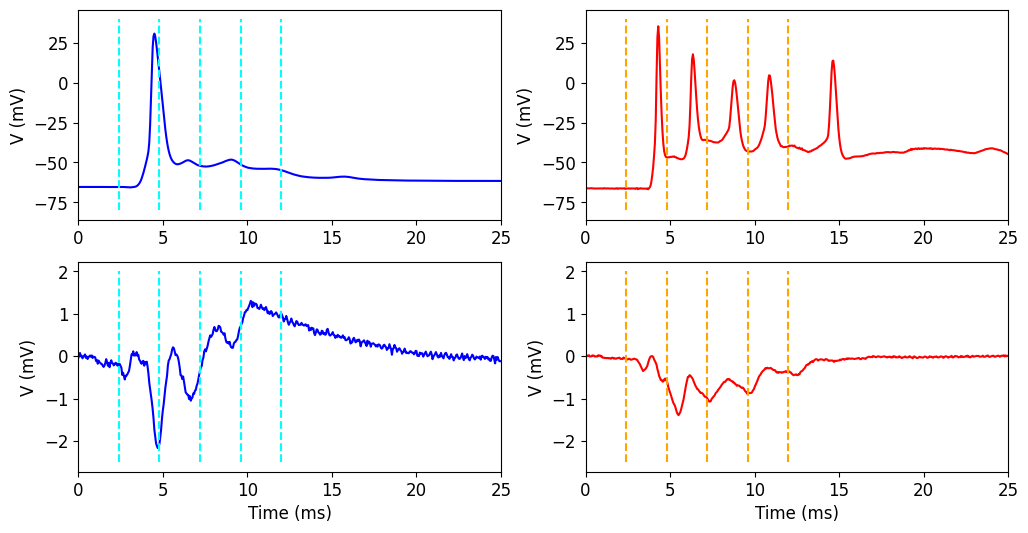

In [58]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.plot(df_rip['102920_DFI_P36'], df_rip['RS 2 ms stim'], color='blue')
plt.vlines(x=[2.4,4.8,7.2,9.6,12.0],ymin=-80, ymax=40, colors='cyan', linestyles='dashed')
plt.ylabel('V (mV)')
plt.xlim(0, 25)
plt.subplot(2, 2, 3)
plt.plot(df_rip['102920_DFI_P36'], df_rip['Field.1'], color='blue')
plt.vlines(x=[2.4,4.8,7.2,9.6,12.0],ymin=-2.5, ymax=2, colors='cyan', linestyles='dashed')
plt.ylabel('V (mV)')
plt.xlabel('Time (ms)')
plt.xlim(0, 25)

plt.subplot(2, 2, 2)
plt.plot(df_rip['031820_DFI_P41'], df_rip['FS 5 ms stim'], color='red')
plt.vlines(x=[2.4,4.8,7.2,9.6,12.0],ymin=-80, ymax=40, colors='orange', linestyles='dashed')
plt.ylabel('V (mV)')
plt.xlim(0, 25)
plt.subplot(2, 2, 4)
plt.plot(df_rip['031820_DFI_P41'], df_rip['Field'], color='red')
plt.vlines(x=[2.4,4.8,7.2,9.6,12.0],ymin=-2.5, ymax=2, colors='orange', linestyles='dashed')
plt.ylabel('V (mV)')
plt.xlabel('Time (ms)')
plt.xlim(0, 25)